# GML HS 2025 - Mini-Challenge 2

**Ausgabe:** Montag, 27. Oktober 2025

**Abgabe:** Sonntag, 23. November 2025, 23:59 Uhr

In [1]:
# DO NOT EDIT THIS CELL
# ADD IMOPRTS IN ASSIGNMENT CELLS

# Notebook configs
%load_ext autoreload
%autoreload 2
%matplotlib inline

from IPython.core.interactiveshell import InteractiveShell
from IPython.display import HTML

InteractiveShell.ast_node_interactivity = "all"

## Vorgaben zu Umsetzung und Abgabe

- Der Code in diesem Notebook muss lauffähig sein bei Ausführung im Docker-Container zum Repo. Nur was durchläuft wird korrigiert.
- Es darf kein Code ausgelagert werden, i.e. sämtlicher Code muss sich im Notebook befinden. Notebooks dürfen weder umbenannt werden, noch soll die Ordnerstruktur im Repo verändert werden.
- Sämtliche Plots sind komplett beschriftet (Achsen, Labels, Überschrift, Colorbar, ..), so dass der Plot ohne den Code zu konsultieren, verstanden werden kann.
- Gib sämtliche relevanten berechneteten Grössen / Metriken mit `print`-Statements aus, e.g. `print('MAE = ', mae)`.
- Als **Abgabe** zählt der letzte Commit vor Abgabetermin in deinem Fork des Repos.  
- **Löschen, kopieren, duplizieren, splitten und verschiebe die vorhandenen Zellen nicht. Für fehlende Antwortzellen gibt es keine Punkte.** Du darfst beliebig viele weitere Zellen hinzufügen (nur via **insert new cell**).
- Laufzeit des Notebooks: Das Notebook sollte in weniger als 30 Minuten ausgeführt werden können.

Für die Erarbeitung der Lösung darf unter Studierenden zusammengearbeitet werden.  
Die Zusammenarbeit ist dabei aber auf konzeptionelle und algorithmische Fragen und Verständnisaspekte beschränkt.  

**Es darf kein Code oder Text kopiert werden, weder vom Internet noch von Mitstudierenden.**

**ChatGPT und ähnliche Sprachmodelle dürfen im Dienst des eigenen Verständnisgewinns beim Lösen der Mini-Challenge verwendet werden. Es dürfen aber keine Lösungen gesamthaft übernommen werden. Zudem muss die gesamte Lösung, Zeile für Zeile und im gesamten Zusammenhang der Aufgabenstellung (in der Defense) erklärt werden können.** 

Beim Vorfinden von kopiertem Code werden alle betroffenen Aufgaben von allen Beteiligten mit 0 Punkten bewertet.


#### Python Module

Neben der Python Standard Library darfst du die folgenden Module immer benutzen: `numpy`, `pandas`, `matplotlib`, `seaborn` (für Progress-Bars).

Du darfst auch generell [sklearn.preprocessing](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.preprocessing), [sklearn.model_selection](https://scikit-learn.org/stable/model_selection.html), [sklearn.pipeline](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.pipeline) und [sklearn.compose](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.compose) verwenden.

Zusätzliche Module darst du nur verwenden wenn dies ausdrücklich erwähnt oder bereits vorgegeben ist in einer Code-Cell.

### Bewertung

Bewertet wird:

- Vollständigkeit (Code, Text)
- Korrektheit (Code, Text)
- Implementation (z.B. Vektorisierung der Operationen, Scikit-Learn API, Visualisierungen, Lesbarkeit Code/Output)

## Einleitung

Das Kantonsspital Aarau arbeitet an einem Forschungsprojekt namens HerzCheck. Ziel des Projekts ist es, mithilfe von Datenanalyse und Machine Learning ein Frühwarnsystem für Herzkrankheiten zu entwickeln.  

Dazu haben die Forschenden eine Stichprobe anonymisierter Patientendaten gesammelt. Jede Zeile des Datensatzes beschreibt eine Person, die sich einer Routineuntersuchung unterzogen hat. Anhand medizinischer Messwerte wie Blutdruck, Cholesterinwert, EKG-Ergebnisse und Belastungstests soll ein Modell lernen, ob bei einem Patienten Anzeichen einer Herzkrankheit vorliegen oder nicht.  

Du wirst angefragt, bei der Entwicklung eines Klassifikationsmodells mitzuhelfen, das aus diesen Daten lernen kann, den Gesundheitszustand (Herzkrankheit: ja/nein) korrekt vorherzusagen.  

Das Modell könnte Ärztinnen und Ärzten später helfen, Risikopatienten frühzeitig zu erkennen und gezielt zu behandeln.  

Der Datensatz der dir überreicht wird ist in Trainings- (`herzcheck_train.csv`) und Testdaten (`herzcheck_test.csv`) unterteilt und beinhaltet folgende Merkmale.  


| Merkmal                           | Beschreibung                                                                                                                                                                                                                           |
| --------------------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Alter**                         | Alter der Patientin oder des Patienten in Jahren                                                                                                                                                                                       |
| **Geschlecht**                    | Geschlecht der Patientin oder des Patienten (M = männlich, F = weiblich)                                                                                                                                                               |
| **Art der Brustschmerzen**        | Typ der auftretenden Brustschmerzen: <br>• **TA** – Typische Angina (klassischer Brustschmerz bei Belastung) <br>• **ATA** – Atypische Angina <br>• **NAP** – Nicht-anginöser Schmerz <br>• **ASY** – Asymptomatisch (keine Schmerzen) |
| **Ruheblutdruck**                 | Blutdruck in Ruhe (in mmHg)                                                                                                                                                                                                            |
| **Cholesterin**                   | Serum-Cholesterinwert (in mg/dl)                                                                                                                                                                                                       |
| **Nüchternblutzucker**            | 1, wenn der Nüchternblutzucker > 120 mg/dl beträgt, sonst 0                                                                                                                                                                            |
| **Ruhe-EKG**                      | Ergebnis des Ruhe-Elektrokardiogramms: <br>• **Normal** – unauffällig <br>• **ST** – ST-T-Wellen-Abnormalität (z. B. ST-Hebung oder -Senkung > 0,05 mV) <br>• **LVH** – Linksherzhypertrophie nach Estes-Kriterien                     |
| **Maximale Herzfrequenz**         | Höchste erreichte Herzfrequenz bei Belastung (zwischen 60 und 202)                                                                                                                                                                     |
| **Belastungsangina**              | Brustschmerz, der bei körperlicher Anstrengung auftritt (Y = ja, N = nein)                                                                                                                                                             |
| **ST-Senkung (Oldpeak)**          | Maß für die Absenkung der ST-Strecke im Belastungs-EKG (in mV); höhere Werte deuten auf mögliche Durchblutungsstörungen des Herzmuskels hin                                                                                            |
| **ST-Streckenneigung (ST Slope)** | Verlauf der ST-Strecke im Belastungs-EKG: <br>• **Up** – ansteigend (normal) <br>• **Flat** – flach (mittleres Risiko) <br>• **Down** – abfallend (Hinweis auf Ischämie)                                                               |
| **Herzkrankheit**                 | Zielvariable der Klassifikation: 1 = Herzkrankheit vorhanden, 0 = gesund                                                                                                                                                               |
|

**Kopiere den Datensatz nach `/data` und lade ihn von da.**

## Aufgabe 1 (8 Punkte)

Verschaffe dir einen Überblick über den Datensatz mittels Visualisierungen und deskriptiver Statistik, sodass du ein gutes Verständnis vom Datensatz bekommst und bereit bist, diesen zu modellieren.  

Erläutere die Ergebnisse der deskriptiven Analyse: Was ist dir aufgefallen? Was sind deine Erwartungen bezüglich der Modellierung der Zielvariablen?

Erörtere, wie du den Datensatz vorzubereiten brauchst, um die Zielvariable mit Hilfe der weiteren Attribute vorherzusagen.  

### Imports

In [2]:
import numpy as np
import pandas as pd

from math import ceil
from collections import defaultdict
from typing import Type, Tuple, Dict
from tqdm.notebook import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score


### Übersicht

In [3]:
try:
    train_df = pd.read_csv("/data/herzcheck_train.csv")
except FileNotFoundError:
    train_df = pd.read_csv("../../data/herzcheck_train.csv")

# Einfache Spaltennahmen
rename_map = {
    'Alter':'Age', 
    'Geschlecht':'Sex', 
    'Art der Brustschmerzen':'ChestPainType',
    'Ruheblutdruck':'RestingBP', 
    'Nüchternblutzucker':'FastingBS',
    'Ruhe-EKG':'RestingECG', 
    'Maximale Herzfrequenz':'MaxHR', 
    'Belastungsangina':'ExerciseAngina',
    'ST-Strecken-Senkung':'Oldpeak', 
    'Steigung der ST-Strecke':'ST_Slope',
    'Herzkrankheit (Zielvariable)':'HeartDisease'
}

train_df.rename(columns={k:v for k,v in rename_map.items() if k in train_df.columns}, inplace=True)

# Ziel und Feature-Typen setzen
TARGET = "HeartDisease"
categorical_cols = ["Sex","ChestPainType","RestingECG","ExerciseAngina","ST_Slope", "FastingBS"]
numeric_cols = ["Age","RestingBP","Cholesterin","MaxHR","Oldpeak",]

# Datentypen glätten
for c in categorical_cols:
    if c in train_df.columns:
        train_df[c] = train_df[c].astype("category")

# Übersicht
display(train_df.head())
print("Form:", train_df.shape)
print("Info:")
print(train_df.info())


,Age,Sex,ChestPainType,RestingBP,Cholesterin,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,65,M,ASY,115,0,0,Normal,93,Y,0.0,Flat,1
1,57,M,ASY,130,207,0,ST,96,Y,1.0,Flat,0
2,58,M,ATA,136,164,0,ST,99,Y,2.0,Flat,1
3,50,M,ASY,140,129,0,Normal,135,N,0.0,Up,0
4,58,M,NAP,105,240,0,LVH,154,Y,0.6,Flat,0


Form: (688, 12)
Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 688 entries, 0 to 687
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   Age             688 non-null    int64   
 1   Sex             688 non-null    category
 2   ChestPainType   688 non-null    category
 3   RestingBP       688 non-null    int64   
 4   Cholesterin     688 non-null    int64   
 5   FastingBS       688 non-null    category
 6   RestingECG      688 non-null    category
 7   MaxHR           688 non-null    int64   
 8   ExerciseAngina  688 non-null    category
 9   Oldpeak         688 non-null    float64 
 10  ST_Slope        688 non-null    category
 11  HeartDisease    688 non-null    int64   
dtypes: category(6), float64(1), int64(5)
memory usage: 37.2 KB
None


### Deskriptives EDA

In [4]:
# Fehlwerte
na_table = train_df.isna().sum().to_frame("missing")
na_table["missing_rate"] = na_table["missing"] / len(train_df)
display(na_table.sort_values("missing_rate", ascending=False))

# Doppelte Zeilen
print("Duplikate:", train_df.duplicated().sum())

# Grundlegende Verteilungen: Zielvariable
if TARGET in train_df.columns:
    print("\nZielvariable (Counts/Rate):")
    counts = train_df[TARGET].value_counts(dropna=False)
    display(pd.DataFrame({"count": counts, "rate": counts/len(train_df)}))

,missing,missing_rate
Age,0,0.0
Sex,0,0.0
ChestPainType,0,0.0
RestingBP,0,0.0
Cholesterin,0,0.0
FastingBS,0,0.0
RestingECG,0,0.0
MaxHR,0,0.0
ExerciseAngina,0,0.0
Oldpeak,0,0.0


Duplikate: 0

Zielvariable (Counts/Rate):


,count,rate
HeartDisease,,
1,383,0.556686
0,305,0.443314


Sehr gut: keine Werte fehlen, Zielvariabeln sind nicht extrem grob unterschiedlich oft vorhanden

In [5]:
# Numerische Gesamtübersicht
display(train_df[numeric_cols].describe().T)

# Gruppierte Kennzahlen nach Zielvariable
if TARGET in train_df.columns:
    grouped_num = train_df.groupby(TARGET)[numeric_cols].agg(['mean','std','median'])
    display(grouped_num)


,count,mean,std,min,25%,50%,75%,max
Age,688.0,53.340116,9.532631,28.0,47.00,54.0,60.0,77.0
RestingBP,688.0,132.720930,18.244276,92.0,120.00,130.0,140.0,200.0
Cholesterin,688.0,198.613372,108.930858,0.0,174.75,222.0,267.0,603.0
MaxHR,688.0,137.341570,24.755478,69.0,120.00,139.0,156.0,202.0
Oldpeak,688.0,0.912791,1.074033,-2.6,0.00,0.7,1.5,6.2


Age                   RestingBP                    \
                   mean      std median        mean        std median   
HeartDisease                                                            
0             50.114754  9.59046   51.0  130.101639  16.785787  130.0   
1             55.908616  8.67804   57.0  134.806789  19.093028  134.0   

             Cholesterin                          MaxHR                    \
                    mean         std median        mean        std median   
HeartDisease                                                                
0             225.013115   72.549982  226.0  148.681967  23.164327  150.0   
1             177.590078  127.089290  217.0  128.310705  22.150959  125.0   

               Oldpeak                   
                  mean       std median  
HeartDisease                             
0             0.435082  0.748232    0.0  
1             1.293211  1.140936    1.2

Ein Serum-Cholesterinwert von 0 ist auffällig. Laut Solan (2024) ist Cholesterin „eine Fettsubstanz, die natürlicherweise im Körper vorkommt. Der Körper nutzt es zur Bildung von Zellmembranen und bestimmten Hormonen.“ Es sollte demnach nie 0 sein.

Solan, M. (2024, June 1). How low should LDL cholesterol go? Harvard Health. https://www.health.harvard.edu/heart-health/how-low-should-ldl-cholesterol-go

### Visuelle EDA
#### Numerische Variabeln

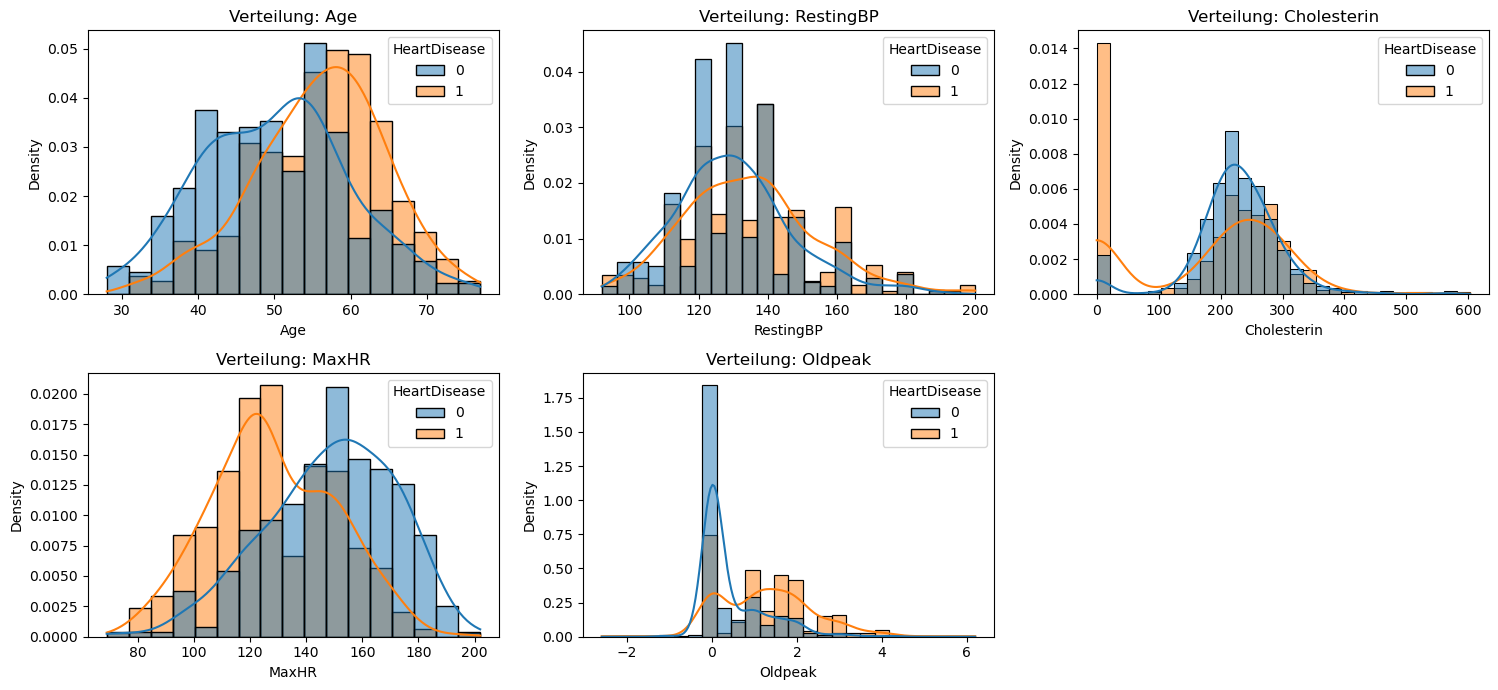

In [6]:
# Hist/KDE für numerische Variablen
ncols = 3
nrows = int(np.ceil(len(numeric_cols) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 3.5*nrows))
axes = axes.ravel()

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    sns.histplot(data=train_df, x=col, hue=TARGET if TARGET in train_df else None, stat="density", common_norm=False, kde=True, ax=ax)
    ax.set_title(f"Verteilung: {col}")
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show();


Auch hier erkennen wir bei der Cholestin-Variable eine häufung beim 0. Dies entspricht aber nicht dem gesamtbild. Es scheint so, als seien diese Werte nicht erfasst worden.

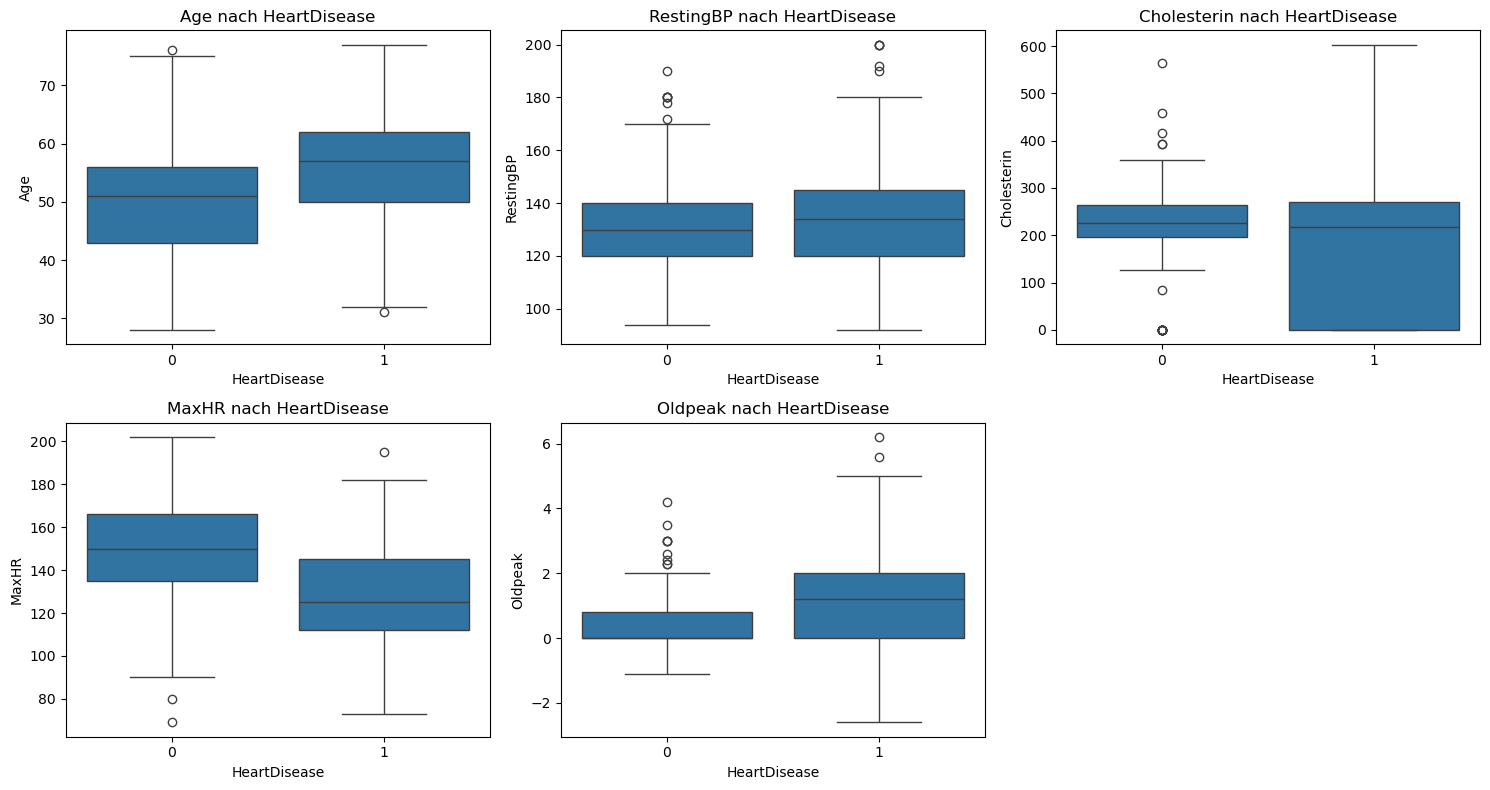

In [7]:
# Boxplots nach Zielvariable 
ncols = 3
nrows = int(np.ceil(len(numeric_cols) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = axes.ravel()
for i, col in enumerate(numeric_cols):
    ax = axes[i]
    sns.boxplot(data=train_df, x=TARGET, y=col, ax=ax)
    ax.set_title(f"{col} nach {TARGET}")
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show();


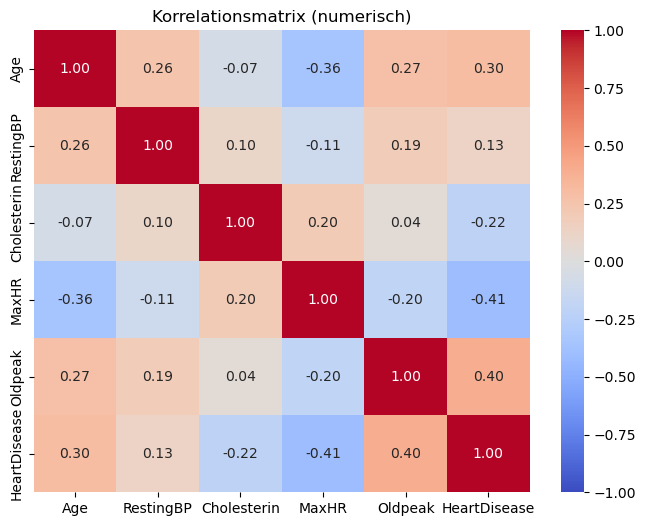

In [8]:
# Numerische Korrelationsmatrix
num_for_corr = [c for c in numeric_cols + [TARGET] if c in train_df.columns]
corr = train_df[num_for_corr].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)

plt.title("Korrelationsmatrix (numerisch)")
plt.show();

In [9]:
means_0 = train_df[train_df[TARGET]==0][numeric_cols].mean()
means_1 = train_df[train_df[TARGET]==1][numeric_cols].mean()
diff = (means_1 - means_0).sort_values(ascending=False).to_frame("mean_diff(1-0)")
display(diff)

,mean_diff(1-0)
Age,5.793862
RestingBP,4.705149
Oldpeak,0.858130
MaxHR,-20.371262
Cholesterin,-47.423036


#### Kategoriale Variablen

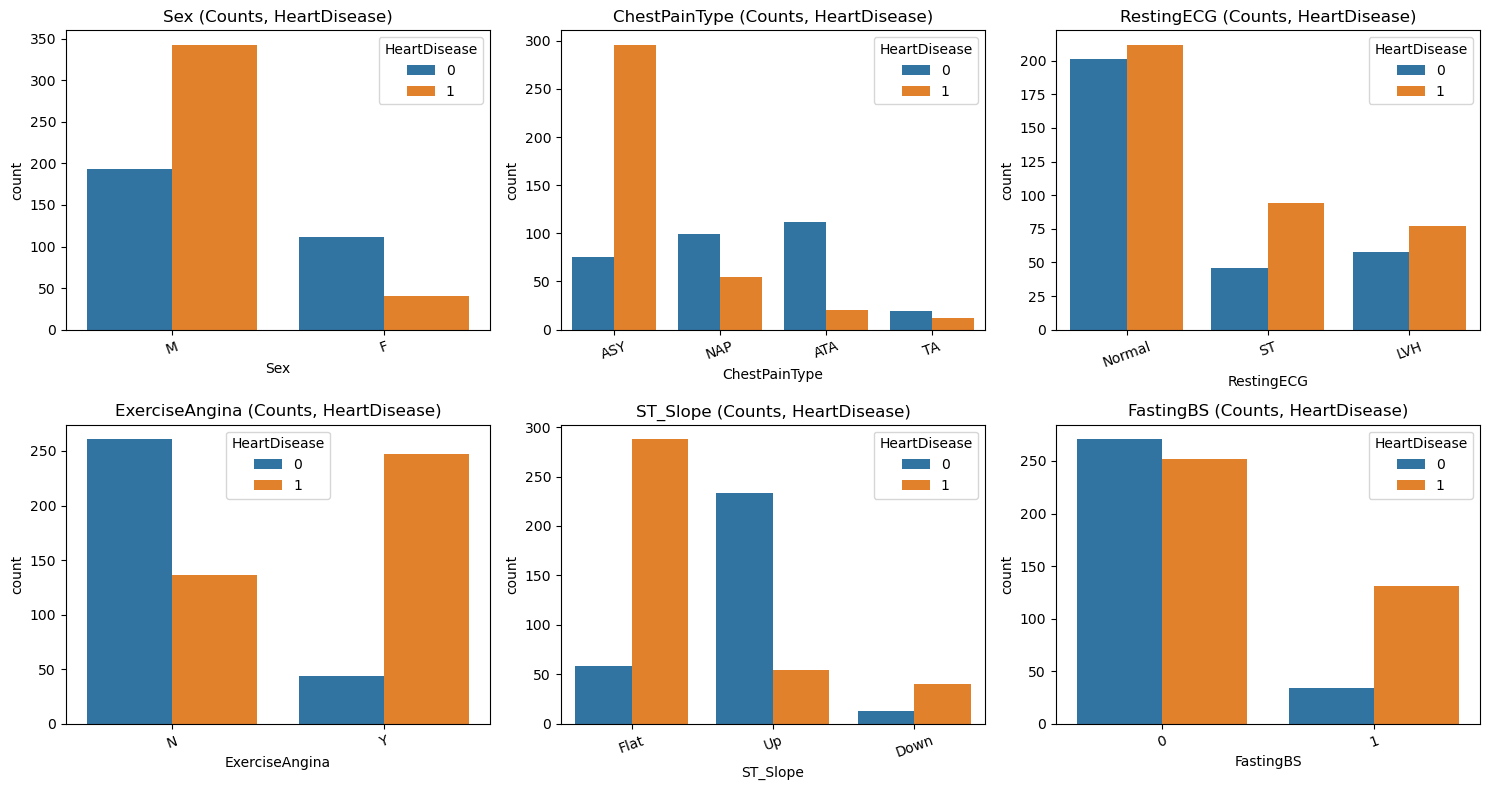

In [10]:
# Balkenplots für kategoriale Variablen
ncols = 3
nrows = int(np.ceil(len(categorical_cols) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = axes.ravel()
for i, col in enumerate(categorical_cols):
    ax = axes[i]
    order = train_df[col].value_counts().index
    sns.countplot(data=train_df, x=col, hue=TARGET if TARGET in train_df else None, order=order, ax=ax)
    ax.set_title(f"{col} (Counts, {TARGET})")
    ax.tick_params(axis='x', rotation=20)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show();


### Überblick

#### Beobachtungen

Die deskriptive Analyse des Trainingsdatensatzes zeigt einen gut aufbereiteten medizinischen Datensatz mit elf Prädiktoren und einer binären Zielvariable `HeartDisease`. Es gibt weder fehlenden Werte im klassischen Sinne noch Duplikate. Allerdings fällt eine unplausible Häufung von `Cholesterol = 0` auf. Dies entspricht keiner realistischen Messung und ist als *fehlender Wert* zu interpretieren.

Die Zielvariable ist leicht unausgewogen: Fälle mit Herzkrankheit sind häufiger, was für die Modellbewertung Metriken wie den F1-Score wichtiger macht als reine Accuracy. Mehrere Merkmale zeigen klare Unterschiede zwischen den Klassen:

* Numerische Variablen:

  * `Age` und `Oldpeak` sind bei Patient:innen **mit** Herzkrankheit tendenziell höher.
  * `MaxHR` ist bei Herzkranken eher **niedriger**.
* Kategoriale Variablen:

  * `ChestPainType = ASY` und `ExerciseAngina = Y` treten deutlich häufiger bei Herzkranken auf.
  * `ST_Slope = Down / Flat` ist stark mit Herzkrankheit assoziiert, `ST_Slope = Up` eher mit Gesunden.
  * Männer (`Sex = M`) sind häufiger in der Herzkrankheitsgruppe vertreten.

Die Korrelationen zwischen den numerischen Merkmalen sind insgesamt moderat, sodass keine starke Multikollinearität zu erwarten ist. Besonders relevant sind die Beziehungen zwischen den Merkmalen `Oldpeak`, `MaxHR`, `Age` sowie der Zielvariable. Insgesamt deuten diese Muster auf eine gute Trennbarkeit der Klassen hin.  Die gefundenen Zusammenhänge sind zudem auch medizinisch plausibel.

#### Datenvorbereitung und Modellierung

Aus den Beobachtungen ergeben sich konkrete Schritte für die weitere Aufbereitung:

* **Umgang mit `Cholesterol = 0`:**
   Diese Werte sollten explizit behandelt werden. Da es viele betroffene Zeilen sind, werden wir sie mit dem Median imputieren.


* **Kodierung kategorialer Merkmale:**
  Nominale Merkmale wie `ChestPainType`, `RestingECG`, `ST_Slope`, `Sex`, `ExerciseAngina` werden per **One-Hot-Encoding** transformiert. Binäre Variablen wie `FastingBS` sind bereits passend kodiert (n-1 klassen nötig).

* **Skalierung numerischer Features:**
  Für abstands- und gradientenbasierte Modelle sollten die numerischen Variablen standardisiert werden (`StandardScaler`).

* **Modell-Pipeline:**
  Mithilfe von `ColumnTransformer` und `Pipeline` können numerische und kategoriale Features getrennt voneinander vorverarbeitet und anschliessend gemeinsam an das Modell übergeben werden.


## Aufgabe 2 - Testdaten (4 Punkte)

Untersuche mit Visualisierungen und deskriptiver Statistik, ob die Testdaten geeignet sind zur Evaluation unserer Modelle.  

Diskutiere deine Einsichten.

In [11]:
try:
    test_df = pd.read_csv("/data/herzcheck_test.csv")
except FileNotFoundError:
    test_df = pd.read_csv("../../data/herzcheck_test.csv")

# Einfache Spaltennahmen
test_df.rename(columns={k:v for k,v in rename_map.items() if k in test_df.columns}, inplace=True)

# Datentypen standartisieren
for c in categorical_cols:
    if c in test_df.columns:
        test_df[c] = test_df[c].astype("category")

### Stabilitäts- & Driftanalyse

Zuerst implementiere ich Kennzahlen, um zu prüfen, ob sich die Verteilungen der Features zwischen Trainings- und Testdaten relevant unterscheiden (**Data / Population Drift**).

Für **numerische Variablen**:

* die **standardized mean difference (SMD)** zur Beurteilung von Lageunterschieden der Mittelwerte:
  $$\text{SMD} = \frac{\mu_{\text{test}} - \mu_{\text{train}}}{s_{\text{pooled}}}, \quad
  s_{\text{pooled}} = \sqrt{\frac{(n_{\text{train}}-1)s_{\text{train}}^2 + (n_{\text{test}}-1)s_{\text{test}}^2}{n_{\text{train}}+n_{\text{test}}-2}}$$
  Größere $|\text{SMD}|$ deuten auf relevante Verschiebungen hin.
* den **Population Stability Index (PSI)** zur Messung von Verteilungssprüngen über Bins:
  $$\text{PSI} = \sum_i (p_i^{\text{test}} - p_i^{\text{train}}),\ln!\left(\frac{p_i^{\text{test}}}{p_i^{\text{train}}}\right)$$
  Hier wird besonders auf erhöhte PSI-Werte geachtet, die auf strukturelle Änderungen der Verteilung hinweisen.

Für **kategoriale Variablen** werden:

* die **Total Variation Distance (TVD)** zwischen den Kategorieproportionen eingesetzt:
  $$\text{TVD}(p,q) = \tfrac{1}{2}\sum_i |p_i - q_i|$$
  Hohe TVD-Werte zeigen starke Verschiebungen im Kategorie-Mix an.
* ein **kategorialer PSI** analog zur obigen Formel berechnet, um Verteilungsänderungen zu erfassen.
* Neue bzw. fehlende **Kategorien** (unseen levels) sowie Änderungen in den **Missing-Raten** zwischen Train und Test identifiziert, da diese die Modellgüte und Vorverarbeitung (z.B. One-Hot-Encoding) direkt beeinflussen.

In [12]:
def standardized_mean_difference(a, b):
    """SMD: (mean_b - mean_a) / pooled_std"""
    a = pd.Series(a).dropna()
    b = pd.Series(b).dropna()
    sa, sb = a.std(ddof=1), b.std(ddof=1)
    pooled = np.sqrt(((len(a)-1)*sa**2 + (len(b)-1)*sb**2) / (len(a)+len(b)-2)) if (len(a)+len(b)-2)>0 else np.nan
    return (b.mean() - a.mean()) / pooled if pooled and pooled>0 else np.nan

def psi_from_quantiles(train_s, test_s, nbins=10):
    """PSI für numerische Variable: Bins über Train-Quantile, dann Test einsortieren."""
    tr = pd.Series(train_s).astype(float)
    te = pd.Series(test_s).astype(float)
    tr = tr.replace([np.inf, -np.inf], np.nan).dropna()
    te = te.replace([np.inf, -np.inf], np.nan).dropna()
    if len(tr)==0 or len(te)==0:
        return np.nan
    
    # Quantilgrenzen (unique sichern)
    quantiles = np.unique(np.quantile(tr, np.linspace(0, 1, nbins+1)))
    
    # Kleine Korrektur: bei Konstanz eine Bin bauen
    if len(quantiles) < 2:
        quantiles = np.array([tr.min()-1e-9, tr.max()+1e-9])
    tr_counts, _ = np.histogram(tr, bins=quantiles)
    te_counts, _ = np.histogram(te, bins=quantiles)
    tr_prop = np.clip(tr_counts / tr_counts.sum(), 1e-6, 1.0)
    te_prop = np.clip(te_counts / te_counts.sum(), 1e-6, 1.0)
    psi = np.sum((te_prop - tr_prop) * np.log(te_prop / tr_prop))
    return float(psi)

def psi_categorical(train_s, test_s):
    """PSI für kategoriale Variable (Bins = Kategorien im Train)."""
    tr = pd.Series(train_s).astype("category")
    te = pd.Series(test_s).astype("category")
    cats = pd.Index(tr.cat.categories).union(pd.Index(te.cat.categories))
    tr_prop = tr.value_counts(normalize=True).reindex(cats, fill_value=0.0).values
    te_prop = te.value_counts(normalize=True).reindex(cats, fill_value=0.0).values
    tr_prop = np.clip(tr_prop, 1e-6, 1.0)
    te_prop = np.clip(te_prop, 1e-6, 1.0)
    psi = np.sum((te_prop - tr_prop) * np.log(te_prop / tr_prop))
    return float(psi)

def total_variation_distance(train_prop, test_prop):
    """TVD = 0.5 * L1-Distanz über kategoriale Verteilungen (∈ [0,1])."""
    return 0.5 * np.sum(np.abs(np.array(test_prop) - np.array(train_prop)))

def unseen_categories(train_s, test_s):
    tr_cats = pd.Series(train_s).dropna().unique().tolist()
    te_cats = pd.Series(test_s).dropna().unique().tolist()
    only_in_test = sorted(list(set(te_cats) - set(tr_cats)))
    only_in_train = sorted(list(set(tr_cats) - set(te_cats)))
    return only_in_test, only_in_train


In [13]:
# Zielprävalenz
print("Zielprävalenz differenz (HeartDisease)")
prev_train = train_df[TARGET].mean()
prev_test  = test_df[TARGET].mean()
print(f"Train: {prev_train:.3f} | Test: {prev_test:.3f} | Δ = {prev_test - prev_train:+.3f}")

Zielprävalenz differenz (HeartDisease)
Train: 0.557 | Test: 0.543 | Δ = -0.013


In [14]:
# Fehlwerte-Raten
print("Fehlwerte pro Spalte (Train vs Test)")
na_train = train_df.isna().mean().rename("na_rate_train")
na_test  = test_df.isna().mean().rename("na_rate_test")
na_cmp = pd.concat([na_train, na_test], axis=1)
na_cmp["delta"] = na_cmp["na_rate_test"] - na_cmp["na_rate_train"]
display(na_cmp.sort_values("delta", ascending=False))

Fehlwerte pro Spalte (Train vs Test)


,na_rate_train,na_rate_test,delta
Age,0.0,0.0,0.0
Sex,0.0,0.0,0.0
ChestPainType,0.0,0.0,0.0
RestingBP,0.0,0.0,0.0
Cholesterin,0.0,0.0,0.0
FastingBS,0.0,0.0,0.0
RestingECG,0.0,0.0,0.0
MaxHR,0.0,0.0,0.0
ExerciseAngina,0.0,0.0,0.0
Oldpeak,0.0,0.0,0.0


In [15]:
# Numerische Variablen
num_rows = []
for col in numeric_cols:
    if col not in train_df.columns: 
        continue
    smd = standardized_mean_difference(train_df[col], test_df[col])
    psi = psi_from_quantiles(train_df[col], test_df[col], nbins=10)
    row = {
        "feature": col,
        "train_mean": train_df[col].mean(),
        "test_mean":  test_df[col].mean(),
        "train_std":  train_df[col].std(ddof=1),
        "test_std":   test_df[col].std(ddof=1),
        "SMD": smd,
        "PSI": psi
    }
    num_rows.append(row)

num_report = pd.DataFrame(num_rows).set_index("feature").sort_values("PSI", ascending=False)
print("Numerisch: SMD & PSI")
display(num_report)


Numerisch: SMD & PSI


,train_mean,test_mean,train_std,test_std,SMD,PSI
feature,,,,,,
MaxHR,137.341570,135.217391,24.755478,27.456288,-0.083440,0.107042
RestingBP,132.720930,131.426087,18.244276,19.307243,-0.069932,0.079521
Age,53.340116,54.021739,9.532631,9.128125,0.072258,0.067508
Oldpeak,0.912791,0.811304,1.074033,1.042525,-0.095181,0.037739
Cholesterin,198.613372,199.356522,108.930858,110.966669,0.006790,0.015347


In [16]:
# Kategoriale Variablen
cat_rows = []
cat_details = {}
for col in categorical_cols:
    if col not in train_df.columns: 
        continue
    tr_prop = train_df[col].value_counts(normalize=True)
    te_prop = test_df[col].value_counts(normalize=True)
    cats = tr_prop.index.union(te_prop.index)
    tvd = total_variation_distance(tr_prop.reindex(cats, fill_value=0.0).values,
                                   te_prop.reindex(cats, fill_value=0.0).values)
    psi = psi_categorical(train_df[col], test_df[col])
    only_test, only_train = unseen_categories(train_df[col], test_df[col])

    # Max absolutes Proportionsdelta
    deltas = (te_prop.reindex(cats, fill_value=0.0) - tr_prop.reindex(cats, fill_value=0.0)).abs()
    max_delta = deltas.max() if len(deltas) else 0.0

    cat_rows.append({
        "feature": col,
        "TVD": tvd,
        "PSI": psi,
        "max_abs_prop_delta": max_delta,
        "n_levels_train": train_df[col].nunique(),
        "n_levels_test": test_df[col].nunique(),
        "unseen_in_test": ", ".join(map(str, only_test)) if only_test else "",
        "missing_train_rate": train_df[col].isna().mean(),
        "missing_test_rate":  test_df[col].isna().mean(),
    })
    # Detailtabelle (Proportionen je Level)
    cat_details[col] = pd.DataFrame({
        "prop_train": tr_prop.reindex(cats, fill_value=0.0),
        "prop_test":  te_prop.reindex(cats, fill_value=0.0),
        "abs_delta": (te_prop.reindex(cats, fill_value=0.0) - tr_prop.reindex(cats, fill_value=0.0)).abs()
    }).sort_values("abs_delta", ascending=False)

cat_report = pd.DataFrame(cat_rows).set_index("feature").sort_values("TVD", ascending=False)
print("Kategorial: TVD, PSI, max Δ, unseen")
display(cat_report)

Kategorial: TVD, PSI, max Δ, unseen


,TVD,PSI,max_abs_prop_delta,n_levels_train,n_levels_test,unseen_in_test,missing_train_rate,missing_test_rate
feature,,,,,,,,
ExerciseAngina,0.075139,0.023894,0.075139,2,2,,0.0,0.0
ST_Slope,0.046613,0.024458,0.046613,3,3,,0.0,0.0
Sex,0.042669,0.011432,0.042669,2,2,,0.0,0.0
RestingECG,0.038271,0.013500,0.038271,3,3,,0.0,0.0
FastingBS,0.026782,0.004099,0.026782,2,2,,0.0,0.0
ChestPainType,0.024393,0.009021,0.020159,4,4,,0.0,0.0


In [17]:
print("Details: Proportionen pro Level")
for col, tab in cat_details.items():
    print(f"\n{col}")
    display(tab.head(5))

Details: Proportionen pro Level

Sex


,prop_train,prop_test,abs_delta
Sex,,,
F,0.22093,0.178261,0.042669
M,0.77907,0.821739,0.042669



ChestPainType


,prop_train,prop_test,abs_delta
ChestPainType,,,
TA,0.045058,0.065217,0.020159
ATA,0.191860,0.178261,0.013600
NAP,0.223837,0.213043,0.010794
ASY,0.539244,0.543478,0.004234



RestingECG


,prop_train,prop_test,abs_delta
RestingECG,,,
ST,0.203488,0.165217,0.038271
LVH,0.196221,0.230435,0.034214
Normal,0.600291,0.604348,0.004057



ExerciseAngina


,prop_train,prop_test,abs_delta
ExerciseAngina,,,
N,0.577035,0.652174,0.075139
Y,0.422965,0.347826,0.075139



ST_Slope


,prop_train,prop_test,abs_delta
ST_Slope,,,
Up,0.418605,0.465217,0.046613
Down,0.077035,0.043478,0.033557
Flat,0.504360,0.491304,0.013056



FastingBS


,prop_train,prop_test,abs_delta
FastingBS,,,
1,0.239826,0.213043,0.026782
0,0.760174,0.786957,0.026782


### Visuelle Checks

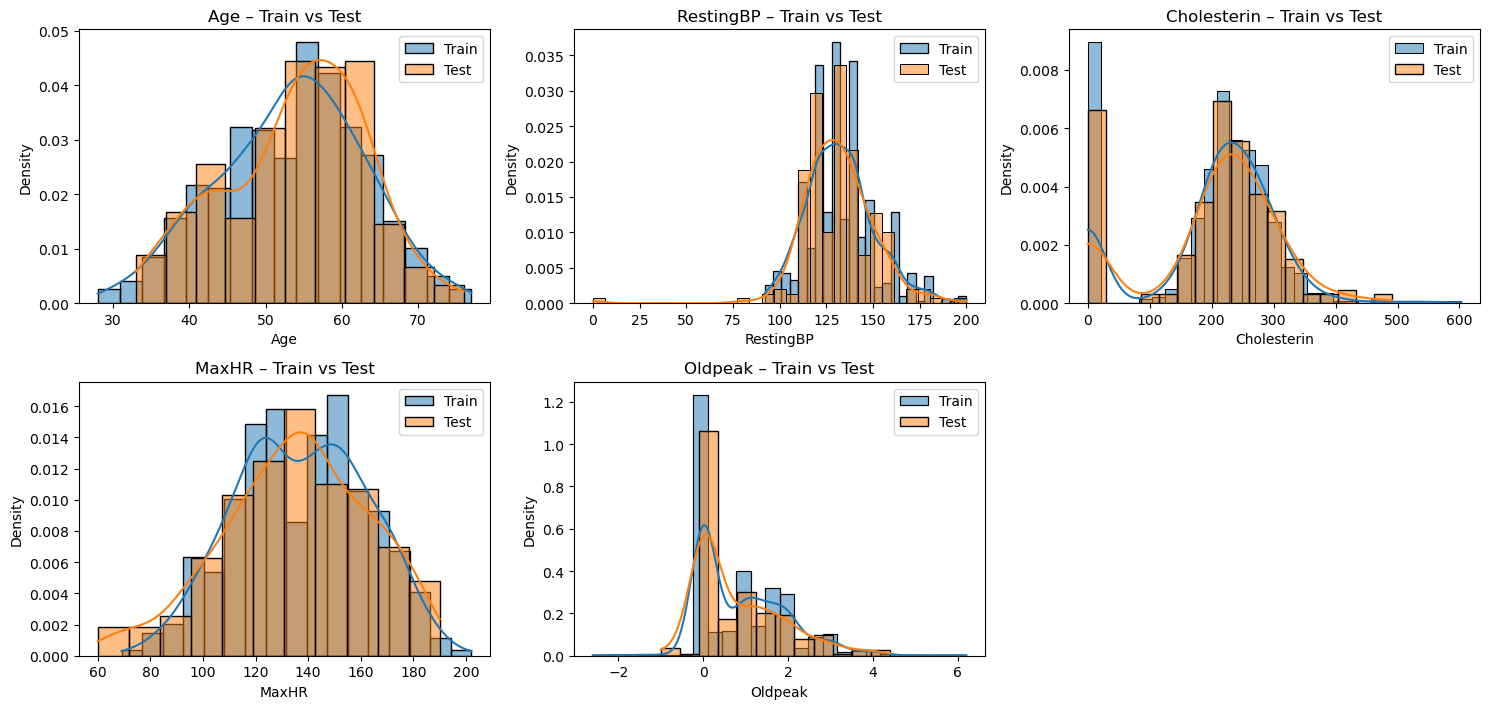

In [18]:
# Numerisch: Verteilungen
ncols = 3
nrows = int(np.ceil(len(numeric_cols)/ncols)) if numeric_cols else 1
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 3.6*nrows))
axes = np.array(axes).reshape(-1)  # robustes Indexing

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    sns.histplot(train_df[col], stat="density", kde=True, label="Train", ax=ax, alpha=0.5)
    sns.histplot(test_df[col],  stat="density", kde=True, label="Test",  ax=ax, alpha=0.5)
    ax.set_title(f"{col} – Train vs Test")
    ax.legend()
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show();

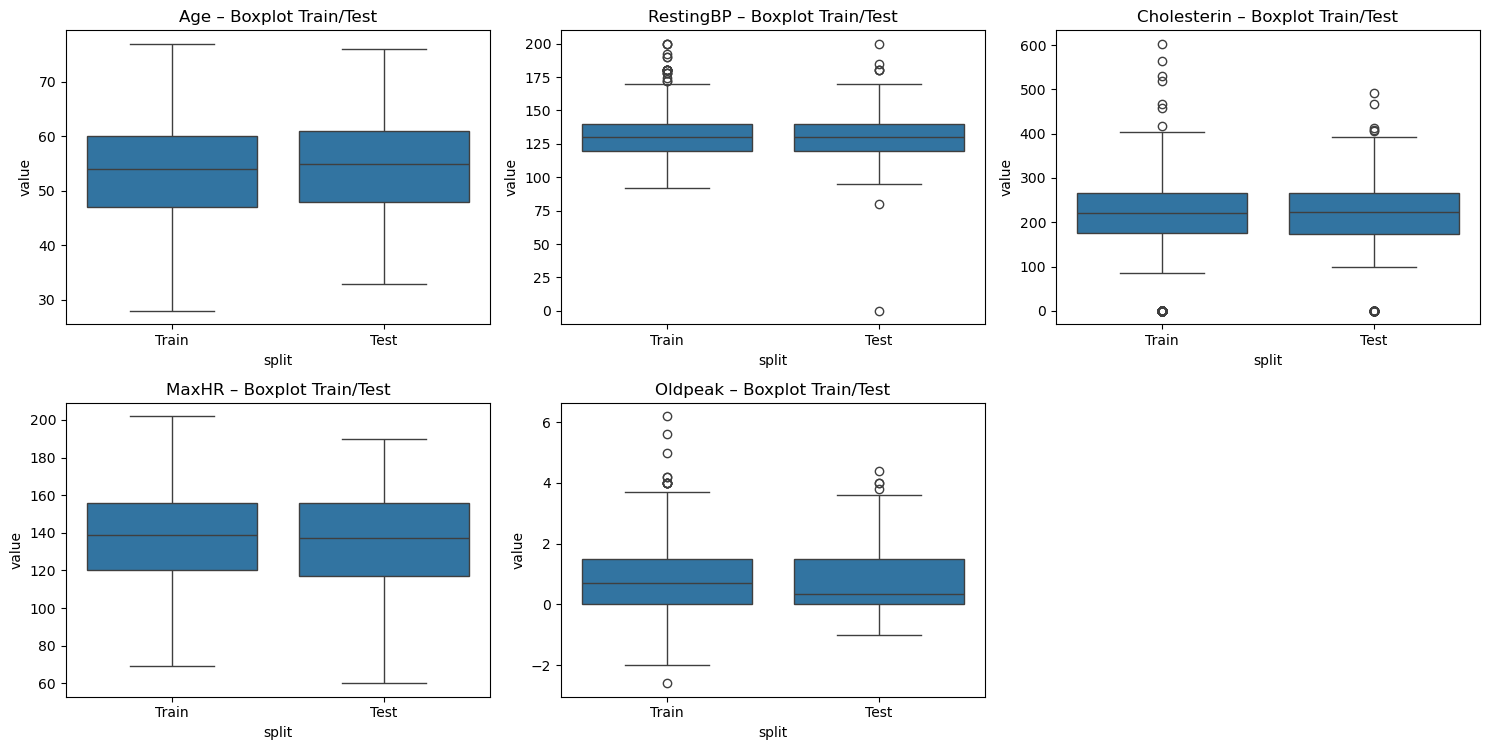

In [19]:
#  Numerisch: Boxplots 
ncols = 3
nrows = int(np.ceil(len(numeric_cols)/ncols)) if numeric_cols else 1
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 3.8*nrows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    sns.boxplot(data=pd.DataFrame({"value": pd.concat([train_df[col], test_df[col]]),
                                   "split": ["Train"]*len(train_df) + ["Test"]*len(test_df)}),
                x="split", y="value", ax=ax)
    ax.set_title(f"{col} – Boxplot Train/Test")
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show();

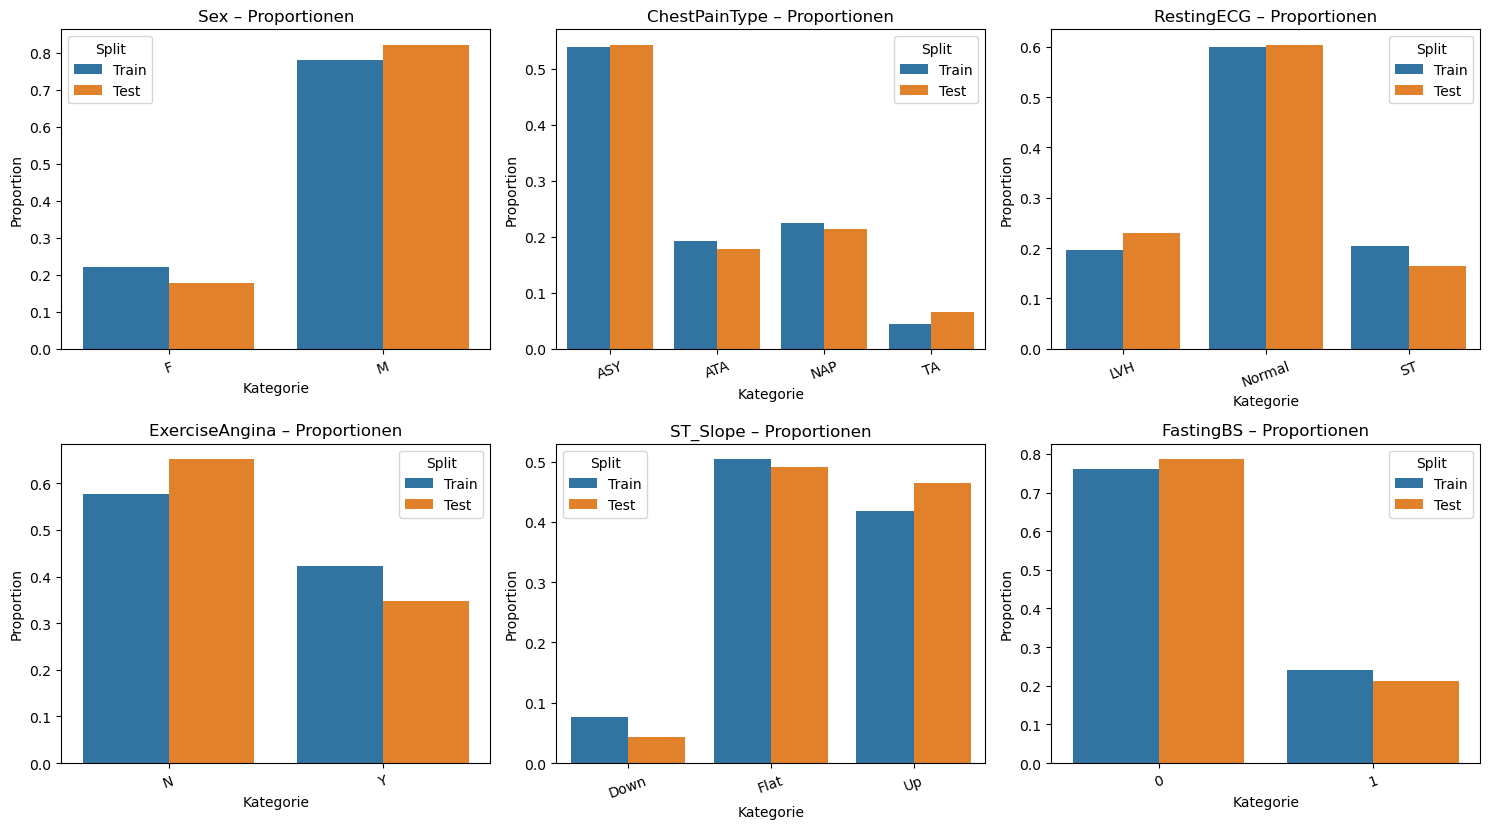

In [20]:
# Kategorial: Proportionsbalken
ncols = 3
nrows = int(np.ceil(len(categorical_cols)/ncols)) if categorical_cols else 1
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4.2*nrows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(categorical_cols):
    ax = axes[i]
    tr = train_df[col].value_counts(normalize=True)
    te = test_df[col].value_counts(normalize=True)
    cats = tr.index.union(te.index)
    plot_df = pd.DataFrame({
        "Kategorie": cats,
        "Train": tr.reindex(cats, fill_value=0.0).values,
        "Test":  te.reindex(cats, fill_value=0.0).values
    }).melt(id_vars="Kategorie", var_name="Split", value_name="Proportion")
    sns.barplot(data=plot_df, x="Kategorie", y="Proportion", hue="Split", ax=ax)
    ax.set_title(f"{col} – Proportionen")
    ax.tick_params(axis='x', rotation=20)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show();


### Eignung der Testdaten

Der Vergleich von Trainings- und Testdatensatz anhand **Zielverteilung, Drift-Metriken (SMD, PSI, TVD)** und Visualisierungen (Histogramme/KDE, Boxplots, Balkendiagramme) zeigt, dass der Testdatensatz **gut für eine faire Modellevaluation geeignet** ist.

* **Zielvariable:** Die Rate von `HeartDisease` ist in Train und Test sehr ähnlich. Das ist wichtig, damit meine Metriken nicht verfälschte Scores ausgeben und ich meine Daten wirklich Testen kann.
* **Fehlwerte / Datenqualität:** Es gibt zwar formal keine Missing Values, aber das bekannte Problem der Cholesterinwerte = 0 tritt in beiden Splits in ähnlicher Häufigkeit auf. Das ist zwar ein inhaltliches Datenproblem, aber immerhin **konsistent**. Die im Training gewählte Strategie (Imputation) lässt sich 1:1 auf den Testdatensatz übertragen.
* **Numerische Features:** Die Standardisierte Mittelwertdifferenz (SMD) und der PSI-Wert liegen für die meisten numerischen Variablen im unproblematischen Bereich (SMD meist < 0,1, PSI < 0,1 bzw. klar < 0,25). Die Verteilungen von `Age`, `RestingBP`, `MaxHR`, `Oldpeak` usw. überlappen sich in Histogrammen und Boxplots gut, sodass Mediane, Quartile und Streuungen vergleichbar sind. Es gibt keine Hinweise auf einen starken Covariate-Shift.
* **Kategoriale Features:** Für Variablen wie `Sex`, `ChestPainType`, `RestingECG`, `ExerciseAngina`, `ST_Slope` und `FastingBS` liegen TVD und PSI durchweg niedrig bis moderat. Alle Kategorien kommen in Train und Test vor, es gibt also keine „unseen categories“, die Probleme beim Encoding machen würden. Kleinere Proportionsunterschiede (z. B. bei einzelnen `ChestPainType`-Ausprägungen) sind im Rahmen und in den Balkendiagrammen gut nachvollziehbar.
* **Visuelle Checks:** Die Plots bestätigen die Kennzahlen: überlappende Dichten, ähnliche Peaks, keine auffälligen Outlier-Häufungen im Testset und keine systematischen Verschiebungen ganzer Verteilungen.

Insgesamt sprechen alle durchgeführten Tests dafür, dass Train- und Testdaten aus der gleichen vERTEILUNG stammen und der Split sinnvoll und repräsentativ ist.

### Bereinigung der Daten
Wie vorhin besprochen, ist das Einzige, was wir tun müssen, um unsere Daten aufzubereiten, die Imputation der fehlenden Cholesterinwerte durch den Median. Dies machen wir für den Test- und den Train-Datensatz unabhängig voneinander, um kein Dataleakage zu erzeugen.

In [21]:
# Impute Cholesterin==0 with the mean of non-zero Cholesterin in each split
def impute_cholesterin_with_mean(df: pd.DataFrame) -> pd.DataFrame:
    """Impute Cholesterin==0 with mean of non-zero Cholesterin."""
    nonzero_mean = df.loc[df['Cholesterin'] != 0, 'Cholesterin'].mean()
    zero_mask = df['Cholesterin'] == 0
    zero_count = zero_mask.sum()
    if zero_count > 0:
        df.loc[zero_mask, 'Cholesterin'] = int(ceil(nonzero_mean))

    return df, nonzero_mean, zero_count


# Impute in Train
train_df, train_nonzero_mean, train_zero_count = impute_cholesterin_with_mean(train_df)


# Test
test_df, test_nonzero_mean, test_zero_count = impute_cholesterin_with_mean(test_df)

# Summary output
print(f"Train: replaced {train_zero_count} zeros with mean {train_nonzero_mean:.3f}")
print(f"Test : replaced {test_zero_count} zeros with mean {test_nonzero_mean:.3f}")

# updated descriptive stats for Cholesterin
print("\nTrain Cholesterin (after):")
print(train_df['Cholesterin'].describe())
print("\nTest Cholesterin (after):")
print(test_df['Cholesterin'].describe())

Train: replaced 128 zeros with mean 244.011
Test : replaced 44 zeros with mean 246.516

Train Cholesterin (after):
count    688.000000
mean     244.194767
std       53.258206
min       85.000000
25%      214.000000
50%      245.000000
75%      267.000000
max      603.000000
Name: Cholesterin, dtype: float64

Test Cholesterin (after):
count    230.000000
mean     246.608696
std       53.581786
min      100.000000
25%      216.000000
50%      247.000000
75%      265.000000
max      491.000000
Name: Cholesterin, dtype: float64


## Aufgabe 3 - Logistic Regression (5 Punkte)

Als Baseline-Modell zur Vorhersage unserer Zielvariable verwenden wir logistische Regression.  

Setze einen einfachen, sinnvoll regularisierten, rein linearen logistischen Regressionsansatz um. Optimiere für F1.  
Verwende dazu scikit-learn.  

Evaluiere das Modell auf dem Testdatensatz im Sinne von F1 und Accuracy und zeichne die Confusion Matrix.  

Diskutiere das Ergebnis.

In [22]:
# Features and target
features = numeric_cols + categorical_cols
X_train = train_df[features]
y_train = train_df[TARGET]
X_test = test_df[features]
y_test = test_df[TARGET]


# Preprocessing-Pipelines
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

# Pipeline with regularized logistic regression
pipe = Pipeline(
    steps=[
        ("pre", preprocessor),
        ("clf", LogisticRegression(solver="liblinear", max_iter=2000, random_state=42)),
    ]
)

# Grid search Grid
param_grid = [
    # Solver:  L2 
    {
        "clf__solver": ["lbfgs", "newton-cg", "newton-cholesky", "sag"],
        "clf__penalty": ["l2"],
        "clf__C": [0.001, 0.01, 0.1, 1.0, 10.0],
        "clf__class_weight": [None, "balanced"],
    },
    # liblinear: L1 und L2
    {
        "clf__solver": ["liblinear"],
        "clf__penalty": ["l1", "l2"],
        "clf__C": [0.001, 0.01, 0.1, 1.0, 10.0],
        "clf__class_weight": [None, "balanced"],
    },
    # saga: L1, L2, elasticnet
    {
        "clf__solver": ["saga"],
        "clf__penalty": ["l1", "l2", "elasticnet"],
        "clf__C": [0.001, 0.01, 0.1, 1.0, 10.0],
        "clf__class_weight": [None, "balanced"],
        "clf__l1_ratio": [0.0, 0.5, 1],  
    },
]


# Grid Search mit F1-Score
lr_gs = GridSearchCV(
    pipe, 
    param_grid, 
    scoring="f1", 
    cv=5, 
    n_jobs=-1, 
    verbose=0
)

lr_gs.fit(X_train, y_train)

best_lr = lr_gs.best_estimator_
print("Best params:", lr_gs.best_params_)
print("Best coefficients:", best_lr.named_steps["clf"].coef_)

/opt/conda/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/opt/conda/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/opt/conda/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/opt/conda/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/opt/conda/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/opt/conda/lib/python3.13/site-packages/sklearn/linear_

,estimator,Pipeline(step...liblinear'))])
,param_grid,"[{'clf__C': [0.001, 0.01, ...], 'clf__class_weight': [None, 'balanced'], 'clf__penalty': ['l2'], 'clf__solver': ['lbfgs', 'newton-cg', ...]}, {'clf__C': [0.001, 0.01, ...], 'clf__class_weight': [None, 'balanced'], 'clf__penalty': ['l1', 'l2'], 'clf__solver': ['liblinear']}, ...]"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


Best params: {'clf__C': 0.1, 'clf__class_weight': None, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}
Best coefficients: [[ 0.22044038  0.01874706  0.19407399 -0.22577097  0.3206765  -0.54898537
   0.54833057  0.83658357 -0.45578971 -0.23100251 -0.15044615 -0.01462546
   0.00570806  0.00826259 -0.38726315  0.38660834 -0.01582266  0.888326
  -0.87315814 -0.48432364  0.48366883]]


In [23]:
print("Best CV F1:", lr_gs.best_score_)
print("Best CV Accuracy:", cross_val_score(best_lr, X_train, y_train, scoring="accuracy", cv=5).mean())

# Evaluate on test set
y_pred = best_lr.predict(X_test)
y_proba = best_lr.predict_proba(X_test)[:, 1]

f1 = f1_score(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)

print("Test F1 = ", f1)
print("Test Accuracy = ", acc)

Best CV F1: 0.8798897790351059
Best CV Accuracy: 0.8633767058076802
Test F1 =  0.8818897637795275
Test Accuracy =  0.8695652173913043


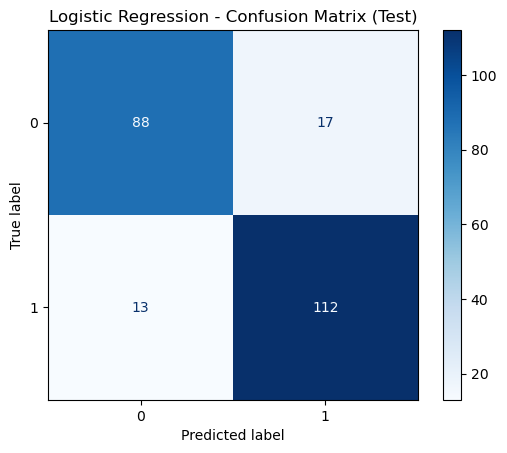

In [24]:


# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_lr.classes_)
disp.plot(cmap="Blues")
plt.title("Logistic Regression - Confusion Matrix (Test)")
plt.show();

#### Diskussion

Die besten gefundenen Parameter lauten:
`C = 0.1`, `class_weight = None`, `penalty = 'l2'`, `solver = 'lbfgs'`. Damit ergibt sich ein klassisches L2-regularisiertes logistisches Regressionsmodell mit relativ starker Regularisierung (kleiner C-Wert) und dem Standard-Solver `lbfgs`. DDie Wahl von `class_weight = None`, deutet darauf hin, dass das Klassenungleichgewicht entweder moderat ist oder eine explizite Gewichtung keine zusätzliche Verbesserung des F1-Scores bringt.

Die Crossvalidation auf dem Trainingsdatensatz liefert einen CV-F1-Score von **etwa 0.880**, was auf eine gute Modellanpassung hinweist. Auf dem Testdatensatz erreicht das finale Modell einen F1-Score von **ca. 0.8819** und eine Accuracy von **ca. 0.8696**. Die Ähnlichkeit von CV-F1 und Test-F1 deutet darauf hin, dass das Modell gut generalisiert und kein starkes Overfitting vorliegt.

Damit liegen 88 True Negatives und 112 True Positives vor. Fälschlicherweise werden 17 Fälle als positiv (False Positives) und 13 Fälle als negativ (False Negatives) klassifiziert. Aus diesen Werten ergeben sich für die positive Klasse eine hohe Präzision und ein hoher Recall, was sich im F1-Score von rund 0,88 widerspiegelt. 

Insgesamt zeigt die Implementierung, dass die logistische Regression in dieser Konfiguration ein leistungsfähiges und gut interpretierbares Basismodell darstellt, an dem sich komplexere Modelle in den folgenden Aufgaben messen lassen müssen.


## Multi-Layer Perceptron

Über die nächsten Aufgaben implementieren wir ein *Multi-Layer Perceptron*. Folgende Vorgaben sollen erfüllt werden:

- Das MLP soll ein _Multi-Class Classification_ Problem mit $k$ Klassen modellieren können.
- Vollständige Konfigurierbarkeit: Architektur (# layers / # units per layer), Regularisierung ($\lambda$), Learning Rate ($\eta$)
- Aktivierungsfunktion in Hidden-Layers soll $ReLU$ oder $Sigmoid$ sein können.
- Initialisiere die Gewichte zufällig mit kleinen Werten, z.B. aus dem Intervall $[-0.7, 0.7]$. 
- Reproduzierbarkeit: Setze _random seeds_ um die Initialisierung der Gewichte reproduzierbar zu machen [siehe numpy](https://numpy.org/doc/stable/reference/random/index.html#random-quick-start).
- Erstelle / ergänze die bereitgestellten Klassen. Du kannst auch neue Methoden oder Argumente hinzufügen.
- score() soll die Accuracy berechnen.
- Die Operationen müssen vektorisiert implementiert werden.
- Implementiere das Modell gemäss sklearn-API.


Es soll folgende Kostenfunktion $J$ minimiert werden (_negative log likelihood_ / _cross-entropy_ mit Regularisierung):

\begin{align}
J(\theta) &= \frac{1}{n}\sum_{i=1}^{n} \sum_{j=1}^{k} \Big(- y_j^{(i)} \log \hat{y}_j^{(i)} \Big) + C \\
C &= \frac{\lambda}{2} \sum_{l=1}^{L} \sum_{i=1}^{u^{(l-1)}} \sum_{j=1}^{u^{(l)}} (\mathbf{W}^{(l)}_{ij})^2
\end{align}

Im folgenden einige Hinweise:

#### Notation

- $n$: Anzahl Datenpunkte
- $L$: Anzahl Layer (ohne Input-Layer)
- $k$: Anzahl Klassen
- $p$: Anzahl Input Features
- $\lambda$: Regularisierungsfaktor
- $\mathbf{a}^{(l)}$ Aktivierungen im Layer $l$ (l=0 ist Input-Layer)
- $\mathbf{z}^{(l)}$ pre-activations / logits im Layer $l$
- $\mathbf{y}^{(i)} \in \{0, 1\}$: One-hot encoded Vektor mit Dimensionalität $\mathbb{R}^k$,  Eintrag 1 indiziert die Klassenzugehörigkeit
- $\hat{y}_k^{(i)}$ Prediction für Klasse $k$, $P(Y=k| x^{(i)})$ 
- $w^{(l)}_{ij}$: Gewicht / Parameter $ij$ von Layer $l$
- $W^{(l)}$ Parameter von Layer $l$ mit $\in \mathbb{R}^{u^{(l-1)} \times u^{(l)}}$
- $b^{(l)}$ Bias Term von Layer $l$ mit $\in \mathbb{R}^{u^{(l)}}$
- $u^{(l)}$: Anzahl Nodes (units) im Layer $l$
- $g()$: Aktivierungsfunktion

#### Struktur eines MLPs

Als Layer bezeichnet man die Kombination aus linearer Transformation und Aktivierungsfunktion: 
\begin{align}
\mathbf{a}^{(l)} &= g\big(\mathbf{a}^{(l-1)T}W^{(l)}  + b^{(l)}\big) 
\end{align}

Hidden-Layers sind dabei Layer die weder direkt mit Input noch Output verbunden sind. Als Input-Layer bezeichnet man die Daten selbst. Als Output-Layer bezeichnet man den letzten Layer.

![Neural Network](nn.png)

#### Forward Pass

Als forward pass bezeichnet man das Prozessieren eines / mehrerer Datenpunkte vom Input zum Output.

Exemplarisch für einen Datenpunk $\mathbf{x}^{(i)}$.

\begin{align*}
\mathbf{a}^{(0)} &= \mathbf{x}^{(i)} \\
\mathbf{z}^{(1)} &= \mathbf{a}^{(0)T}W^{(1)} + b^{(1)T} \\
\mathbf{a}^{(1)} &= g(\mathbf{z}^{(1)})\\
.. &= .. \\
\mathbf{z}^{(l)} &= \mathbf{a}^{(l-1)T}W^{(l)}  + b^{(l)T} \\
\mathbf{a}^{(l)} &= g(\mathbf{z}^{(l)}) \\
.. &= .. \\
\mathbf{\hat{y}}_k^{(i)} &= a_k^{(L)} 
\end{align*}

Wobei:

\begin{align*}
g(\mathbf{z}^{(l)}) &=  \text{ReLU}(z^{(l)}) & \text{ReLU Aktivierungsfunktion für Hidden-Layers } (l \lt L)  \\
a_i^{(L)} &=  \text{softmax}(z^{(l)})  & \text{ Softmax-Funktion for } l = L
\end{align*}

#### Backpropagation

Backpropagation ist der zentrale Algorithmus beim Trainieren von neuronalen Netzwerken um die partiellen Ableitung der Loss-Funktion bezüglich der Parameter zu berechnen. Dabei wird der Gradient der Loss-Funktion $\nabla_{\theta} J$ vom Output des Netzwerkes mit Hilfe der Kettenregel zurückpropagiert. Sie sollten diesen Algorithmus anwenden um alle $\frac{\partial J}{\partial \mathbf{w_{ij}^{(l)}}}$ sowie $\frac{\partial J}{\partial \mathbf{b_{j}^{(l)}}}$ zu bestimmen. Folgende Zusammenhänge sind hilfreich bei der Implementation und zeigen die Situation bei $n=1$.

\begin{align*}
\frac{\partial \mathbf{a}^{(l)}}{\partial \mathbf{z}^{(l)}} &= \begin{cases}
1, & \text{where } \mathbf{z}^{(l)} \gt 0 \\
0, & \text{where } \mathbf{z}^{(l)} \leq 0
\end{cases} & \text{for } l \lt L \text{ if } g(x)=\text{ReLU}\\
\frac{\partial \mathbf{z}^{(l)}}{\partial \mathbf{a}^{(l-1)}} &= \mathbf{W}^{(l)} \\
\frac{\partial \mathbf{z}^{(l)}}{\partial \mathbf{w}^{(l)}} &= \mathbf{a}_i^{(l-1)}
\end{align*}


Man kann den Gradienten der Kostenfunktion bezüglich der Gewichte $W$ rekursiv bestimmen:

\begin{align*}
\frac{\partial J}{\partial \mathbf{z}^{(L)}} = \frac{\partial J}{\partial \mathbf{a}^{(L)}} &= \delta^{(L)} = \mathbf{\hat{y}} - \mathbf{y} & \text{initialize back-prop with this}\\
\frac{\partial J}{\partial \mathbf{a}^{(l-1)}}  = \delta^{(l-1)} &= \Big( \delta^{(l)} \odot \frac{\partial \mathbf{a}^{(l)}}{\partial \mathbf{z}^{(l)}} \Big) \Big(\frac{\partial \mathbf{z}^{(l)}}{\partial \mathbf{a}^{(l-1)}}\Big)^T & \text{for backpropagation}\\
\frac{\partial J}{\partial \mathbf{W}^{(l)}} &=  \big(\frac{\partial \mathbf{z}^{(l)}}{\partial W^{(l)}}\big)^T \big(\delta^{(l)} \odot \frac{\partial \mathbf{a}^{(l)}}{\partial \mathbf{z}^{(l)}}\big)  & \text{gradients for the weights, this is what we want!} \\
\frac{\partial J}{\partial \mathbf{b}^{(l)}} &=  \big(\delta^{(l)} \odot \frac{\partial \mathbf{a}^{(l)}}{\partial \mathbf{z}^{(l)}}\big)   & \text{gradients for the biases, this is what we want!}
\end{align*}


Die analytische Herleitung des Algorithmus sprengt den Rahmen hier. Wenn du aber mehr dazu lesen möchten, findest du eine gute Herleitung hier:

- [CS229 Stanford](https://cs229.stanford.edu/notes2020spring/cs229-notes-deep_learning.pdf)

Zum Thema Backpropagation gibt es ausserdem ausgezeichnete Videos:

- [3Blue1Brown Video 1](https://youtu.be/IHZwWFHWa-w)

- [3Blue1Brown Video 2](https://youtu.be/Ilg3gGewQ5U)



#### Vektorisierung

Wir können den Forward-Pass und die Backpropagation effizient berechnen, indem wir die Operationen vektorisieren. Wir berechnen die Aktivierungen direkt für alle $n$ Datenpunkte. Auch die Backpropagation lässt sich vektorisieren, wir berechnen dann **_den mittleren Gradienten_** über alle Datenpunkte. Ohne Vektorisierung wird ihre Implementation zu langsam sein. Hier der Ablauf für die Forward-Propagation:


\begin{align*}
\mathbf{X} & \in \mathbb{R}^{n \times p} \\
\mathbf{A}^{(l)} & \in \mathbb{R}^{n \times u_{l}} \\
\mathbf{W}^{(l)} & \in \mathbb{R}^{u_{l-1} \times u_{l}} \\
\mathbf{b}^{(l)} & \in \mathbb{R}^{u_{l} \times 1}
\end{align*}

Allgemein formuliert wäre das:

\begin{align*}
\mathbf{Z}^{(l-1)} &= \mathbf{A}^{(l-1)} \mathbf{W}^{(l)} + \mathbf{b}^{(l)T} \\
\mathbf{A}^{(l)} &= g( \mathbf{Z}^{(l-1)})
\end{align*}

Wobei $\mathbf{A}^{(0)} = \mathbf{X}$.


## Aufgabe 4 -  MLP Module (8 Punkte)
Als erstes implementierst du verschiedene Python-Klassen, die Komponenten / Module in unserem MLP repräsentieren. Diese Vorgehensweise ist angelehnt an _Deep Learning Frameworks_, wie z.B. `PyTorch`. Wie immer, werden wir danach einen `sklearn`-kompatiblen _Estimator_ implementieren.
Vervollständige die folgenden Klassen:

- ReluActivation
- SigmoidActivation
- LinearLayer
- Softmax

Die `forward()` Methode definiert jeweils die _Forward Propagation_ durch die entsprechende Operation.

Die `backward()` Methode definiert jeweils die _Backpropagation_ durch den entsprechenden Operation.


Die Ableitung der ReLU kannst folgendermassen implementieren:

\begin{equation}
\frac{d \text{ReLU}(x)}{d x} = \begin{cases}
1, & \text{if } x \gt 0 \\
0, & \text{if } x \leq 0
\end{cases}
\end{equation}

Die Funktionalität für SigmoidActivation recherchierst du selber.

Für Softmax gilt:

- `backward()`: soll den Gradienten der _negative loglikelihood_ Kostenfunktion $\frac{\partial J}{\partial \mathbf{z}^{(l)}} = \text{softmax}(\mathbf{z}^{(l)}) - \mathbf{y}$ ausgeben. Damit wird _backpropagation_ gestartet.
- Implementiere eine numerisch stabile Version von Softmax. Lese dazu folgenden Abschnitt: [Link](https://ogunlao.github.io/2020/04/26/you_dont_really_know_softmax.html#numerical-stability-of-softmax)


### Activation Functions

Wir definieren eine abstrakte Klasse *ActivationFunction*, welche die grundlegende Struktur für Aktivierungsfunktionen vorgibt. Diese Klasse stellt die Methoden zur Berechnung der Aktivierung sowie deren Ableitung zur Verfügung, die in jeder spezifischen Implementierung umgesetzt werden müssen.

Es wurden drei Aktivierungsfunktionen realisiert: **ReLU**, **Sigmoid** und **Softmax**.

Diese Aktivierungsfunktionen ermöglichen es, die linearen Ausgaben der jeweiligen Schichten in nichtlineare Transformationen zu überführen um komplexe Zusammenhänge in neuronalen Netzen zu modellieren.


In [25]:
# Definieren einer abstrakten Basisklasse für Aktivierungsfunktionen

class ActivationFunction:
    def __init__(self):
        self.input = None

    def __repr__(self):
        return f"{self.__class__.__name__}()"
    
    def __str__(self):
        return self.__class__.__name__

    def forward(parameter_list) -> np.ndarray:
        """
        docstring
        """
        raise NotImplementedError("forward() muss in der Unterklasse implementiert werden.")

    def backward(parameter_list) -> np.ndarray:
        """
        docstring
        """
        raise NotImplementedError("backward() muss in der Unterklasse implementiert werden.")

#### ReLU (Rectified Linear Unit)

**Funktion:**  
$$
f(x) = \max(0, x)
$$

**Ableitung:**  
$$
f'(x) =
\begin{cases}
1 & \text{wenn } x > 0, \\
0 & \text{wenn } x \leq 0.
\end{cases}
$$

In [26]:
class ReLU(ActivationFunction):
    """
    ReLU-Aktivierungsfunktion (Rectified Linear Unit).

    Setzt alle negativen Eingabewerte auf 0, positive bleiben unverändert.
    """
    def __init__(self):
        """Initialisiert die ReLU-Funktion."""
        self.input = None

    def forward(self, x: np.ndarray) -> np.ndarray:
        """
        Führt den Forward-Pass der ReLU-Funktion durch.

        Args:
            x (np.ndarray): Eingabedaten.

        Returns:
            np.ndarray: Ausgabe, bei der alle negativen Werte zu 0 werden.
        """
        if not isinstance(x, np.ndarray):
            raise TypeError("Eingabe x muss ein NumPy Array sein.")
        self.input = x
        return np.maximum(0, x)

    def backward(self, grad_output: np.ndarray) -> np.ndarray:
        """
        Berechnet den Gradienten des Loss bzgl. der Eingabe der ReLU-Funktion.

        Args:
            grad_output (np.ndarray): Gradienten des Loss bzgl. der Ausgabe.

        Returns:
            np.ndarray: Gradienten des Loss bzgl. der Eingabe.
        """
        if self.input is None:
            raise RuntimeError("forward() muss vor backward() aufgerufen werden.")
        if not isinstance(grad_output, np.ndarray):
            raise TypeError("grad_output muss ein NumPy Array sein.")
        
        return grad_output * (self.input > 0)

#### Sigmoid

**Funktion:**  
$$
f(x) = \frac{1}{1 + e^{-x}}
$$

**Ableitung:**  
$$
f'(x) = f(x) \cdot (1 - f(x))
$$

In [27]:
class Sigmoid(ActivationFunction):
    """
    Sigmoid-Aktivierungsfunktion.

    Gibt Werte zwischen 0 und 1 zurück und eignet sich damit z.B. für den Output-Layer bei Binary Classification.
    """
    def __init__(self):
        """Initialisiert die Sigmoid-Funktion."""
        self.out = None

    def forward(self, x: np.ndarray) -> np.ndarray:
        """
        Führt den Forward-Pass der Sigmoid-Funktion durch.

        Args:
            x (np.ndarray): Eingabedaten.

        Returns:
            np.ndarray: Sigmoid-Ausgabe.
        """
        if not isinstance(x, np.ndarray):
            raise TypeError("Eingabe x muss ein NumPy Array sein.")
        self.out = 1 / (1 + np.exp(-x))
        return self.out

    def backward(self, grad_output: np.ndarray) -> np.ndarray:
        """
        Berechnet den Gradienten des Loss bzgl. der Eingabe der Sigmoid-Funktion.

        Args:
            grad_output (np.ndarray): Gradienten des Loss bzgl. der Ausgabe.

        Returns:
            np.ndarray: Gradienten des Loss bzgl. der Eingabe.
        """
        if self.out is None:
            raise RuntimeError("forward() muss vor backward() aufgerufen werden.")
        return grad_output * self.out * (1 - self.out)

#### Softmax

**Funktion:**  
Softmax transformiert einen Eingabevektor \( $\mathbf{z}$ \) in einen Wahrscheinlichkeitsvektor, bei dem jede Komponente \( $f(\mathbf{z})_i$ \) zwischen 0 und 1 liegt und die Summe aller Komponenten 1 ergibt:
$$
f(\mathbf{z})_i = \frac{e^{z_i}}{\sum_{j} e^{z_j}}
$$

**Numerische Stabilität:**  
Um numerische Instabilitäten zu vermeiden, wird vor der Berechnung der Exponentialfunktion der maximale Wert jeder Zeile subtrahiert:
$$
x_{\text{shifted}} = x - \max(x, \text{axis}=1)
$$

**Ableitung:**  
Die vollständige Ableitung (Jacobian) der Softmax-Funktion, welche die gegenseitige Abhängigkeit der Komponenten berücksichtigt, lautet:
$$
\frac{\partial f(\mathbf{z})_i}{\partial z_j} =
\begin{cases}
f(\mathbf{z})_i \cdot (1 - f(\mathbf{z})_i) & \text{wenn } i = j, \\
- f(\mathbf{z})_i \cdot f(\mathbf{z})_j & \text{wenn } i \neq j.
\end{cases}
$$

**Vereinfachte Backward-Berechnung mit Kreuzentropie (CCE) oder Negative Loglikelihood (NLL):**  
Wird Softmax als Ausgangsaktivierung zusammen mit der Kreuzentropie-Loss der Negativen Lolikelihood verwendet, vereinfacht sich die Ableitung massiv. Es ergibt sich für den Gradienten der Loss-Funktion bezüglich der Eingaben \( $\mathbf{z}$ \):
$$
\frac{\partial L}{\partial \mathbf{z}_i} = \text{softmax}(\mathbf{z}_i) - y_i
$$
wobei \( $y_i$ \) der entsprechende Wert des One-Hot-kodierten Zielvektors ist.

Da in der Aufgabenstellung beschrieben ist, dass wir Softmax als AKtivierungsfunktion nur in Kombination mit der NLL verwenden werden (im letzten layer) überspringen ich die Implementierung hier. Ich gebe einfach denn Gradienten der Lossfucntion (in unserem fall nur NLL) weiter. Dadurch bleibt der Ansatz skalierbarer um z.B auch andere loss wie denn CCE zu verwenden.


In [28]:
class Softmax(ActivationFunction):
    """
    Softmax-Aktivierungsfunktion, die die Eingabe zeilenweise normalisiert, sodass die
    Ausgaben als Wahrscheinlichkeiten interpretiert werden können.

    Die Forward-Methode berechnet für jedes Sample:
        softmax(x)_i = exp(x_i) / sum_j(exp(x_j))
    
    Die backward()-Methode setzt voraus, dass Softmax als
    Ausgangsaktivierung in Kombination mit der Kreuzentropie-Loss verwendet wird.
    """
    
    def __init__(self):
        """Initialisiert den Softmax Layer."""
        self.out = None

    def forward(self, x: np.ndarray) -> np.ndarray:
        """
        Führt den Forward-Pass der Softmax-Aktivierungsfunktion durch.

        Args:
            x (np.ndarray): Eingabedaten, Shape (batch_size, n_features).

        Returns:
            np.ndarray: Softmax-Ausgabe, Shape (batch_size, n_features).
        """
        if not isinstance(x, np.ndarray):
            raise TypeError("x muss ein NumPy Array sein.")
        
        # Numerische Stabilität: Subtrahiere den Maximalwert jeder Zeile
        x_shifted = x - np.max(x, axis=1, keepdims=True)
        exp_x = np.exp(x_shifted)
        self.out = exp_x / np.sum(exp_x, axis=1, keepdims=True)
        return self.out

    def backward(self, grad_output: np.ndarray) -> np.ndarray:
        """
        Angepasste Backward-Methode für Softmax in Kombination mit der 
        Kreuzentropie-Loss. Hier wird auf die explizite Berechnung des 
        Softmax-Jacobians verzichtet, da der kombinierte Gradient bereits 
        (y_pred - y_true)/N korrekt ist.

        Args:
            grad_output (np.ndarray): Gradienten des Loss bzgl. der Ausgabe.

        Returns:
            np.ndarray: Gradienten des Loss bzgl. der Eingabe.
        """
        if self.out is None:
            raise RuntimeError("forward() muss vor backward() aufgerufen werden.")
        
        # Die Berechnung des Gradienten ist hier vereinfacht, da wir SoftMax nur in Kombination mit CCE verwenden. 
        return grad_output

### Lossfunctions

Wir definieren eine abstrakte Klasse *LossFunction*, welche die abstrakten Methoden zur Verfügung stellt, die in jeder LossFunction implementiert werden müssen. 
In der Implementierung habe ich die einzige in der Aufgabenstellung erwähnte Kostenfunktion implementieret und zwar **Negative Losslikelihood (NLL)**

Diese Implementierungen ermöglichen es , den Fehler während des Trainings zu berechnen und die entsprechenden Gradienten im Backward-Pass zur Optimierung der Modellparameter zu verwenden.


In [29]:
class LossFunction:
    """
    Basis-Klasse für Verlustfunktionen.

    Diese Klasse definiert die Struktur für Verlustfunktionen und stellt sicher,
    dass alle spezifischen Verlustfunktionen die Methoden forward() und backward()
    implementieren.
    """

    def funcname(parameter_list):
        """
        docstring
        """
        pass


    def __repr__(self):
        return f"{self.__class__.__name__}()"
    
    def __str__(self):
        return self.__class__.__name__

    @staticmethod
    def loss(parameter_list):
        """
        docstring
        """
        raise NotImplementedError("loss() muss in der Unterklasse implementiert werden.")
    
    @staticmethod
    def gradient(parameter_list):
        """
        docstring
        """
        raise NotImplementedError("gradient() muss in der Unterklasse implementiert werden.")

#### Negative Log-Likelihood (NLL)

Die **Negative Log-Likelihood** wird bei Mehrklassenklassifikation verwendet.
**Formel:**
$$
L(y, \hat{p}) = -\frac{1}{n}\sum_{i=1}^{n} \log\big(\hat{p}_{i,,y_i}\big)
$$
wobei:

* $y_i$ der Klassenindex des $i$-ten Beispiels ist,
* $\hat{p}_{i,,y_i}$ die vorhergesagte Wahrscheinlichkeit für die wahre Klasse ist,
* $n$ die Anzahl der Beispiele im Batch ist.

**Äquivalente One-Hot-Form:**
$$
L(Y, \hat{p}) = -\frac{1}{n}\sum_{i=1}^{n}\sum_{j=1}^{C} Y_{i,j},\log(\hat{p}_{i,j})
$$

**Ableitung (Gradient) mit Softmax im Output-Layer (bzgl. Logits (z)):**
$$
\frac{\partial L}{\partial z}=\frac{\mathrm{softmax}(z)-Y}{n}
$$


In [30]:
class NegativeLogLikelihood(LossFunction):
    """
    Implementierung der Negative Log-Likelihood als Verlustfunktion.
    
    Diese Klasse implementiert die Loss-Funktion und den zugehörigen Gradienten
    für mehrklassige Klassifikationsaufgaben.
    
    Annahmen:
    - y_pred: Vorhersagen als Wahrscheinlichkeiten (Werte in (0,1)), Shape (batch_size, num_classes)
    - y_true: Klassenindizes, Shape (batch_size,) oder One-Hot kodiert, Shape (batch_size, num_classes)
    """

    def __init__(self):
        super().__init__()
        self.name = "NegativeLogLikelihood"
    
    @staticmethod
    def loss(y_pred: np.ndarray, y_true: np.ndarray) -> float:
        """
        Berechnet den mittleren Negative Log-Likelihood Loss.
        
        Args:
            y_pred (np.ndarray): Vorhersagen, Shape (batch_size, num_classes).
            y_true (np.ndarray): Klassenindizes, Shape (batch_size,) oder 
                                 One-Hot kodiert, Shape (batch_size, num_classes).
            
        Returns:
            float: Durchschnittlicher NLL-Loss.
        """
        eps = 1e-12  # Für numerische Stabilität
        y_pred = np.clip(y_pred, eps, 1 - eps)
        
        # Wenn y_true One-Hot-kodiert ist, konvertiere zu Klassenindizes
        if y_true.ndim == 2:
            y_true = np.argmax(y_true, axis=1)
        
        batch_size = y_pred.shape[0]
        # Berechne -log(p) für die korrekten Klassen
        log_likelihood = -np.log(y_pred[np.arange(batch_size), y_true])
        loss = np.mean(log_likelihood)
        
        return loss
    
    @staticmethod
    def gradient(y_pred: np.ndarray, y_true: np.ndarray) -> np.ndarray:
        """
        Berechnet den Gradienten des Negative Log-Likelihood Loss bzgl. y_pred.
        
        Args:
            y_pred (np.ndarray): Vorhersagen, Shape (batch_size, num_classes).
            y_true (np.ndarray): Klassenindizes, Shape (batch_size,) oder
                                 One-Hot kodiert, Shape (batch_size, num_classes).
            
        Returns:
            np.ndarray: Gradienten, Shape (batch_size, num_classes).
        """
        eps = 1e-12  # Für numerische Stabilität
        y_pred = np.clip(y_pred, eps, 1 - eps)

        
        grad = (y_pred - y_true) / y_true.shape[0]
        return grad

### Linear Layer
Wir erstellen ein standartmässiges Lineares layer.

#### Forward Pass: 

$ f(\mathbf{X} ) = \mathbf{X} \cdot \mathbf{W} + \vec{b}$

#### Back Propagation
In der Backpropagation werden verschiedene Berechnungen ausgeführt:
**Gradient der Gewichte**
$ \frac{\partial L}{\partial W} = \frac{\partial Z}{\partial W} \cdot \frac{\partial L}{\partial Z}$

$ \frac{\partial Z}{\partial W} = X^T $


Es folgt:
$ \frac{\partial L}{\partial W} = X^T \cdot \frac{\partial L}{\partial Z}$ 

**Gradient des Bias**
$ \frac{\partial L}{\partial b} = \sum (\frac{\partial L}{\partial Z}) $

**Gradient des Input (Loss für das vorhergehende Layer)**

$ \frac{\partial L}{\partial X} =  \frac{\partial L}{\partial Z}  \cdot \frac{\partial Z}{\partial W}  $

$ \frac{\partial L}{\partial X} =  \frac{\partial L}{\partial Z}  \cdot \mathbf{W} ^T $

#### Parameterupdate

**Update der Weights**
$   \mathbf{W} = \mathbf{W} - \alpha \frac{\partial L}{\partial W}$

**Update des Bias**
$   \vec{b} = \vec{b} - \alpha \frac{\partial L}{\partial b}$

#### Weight Initialisation

Wir initialisiern unsere Gewichte Standardmässig mit der **Xavier-Initialisierung**. Beim Output Layer werden die Gewichte gemäss der Standardabweichung
$$ 
\sigma = \sqrt{\frac{2}{n_{\text{in}} + n_{\text{out}}}}
$$
 
mit Hilfe der Anzahl Inputs ($n_{\text{in}}$) und Anzahl Neuronen $n_{\text{out}}$ initialisiert, um eine stabile Verteilung der Aktivierungen bei der Sigmoid-Funktion zu gewährleisten.

In [31]:
class DenseLayer:
    """
    Dichte Schicht (Fully Connected Layer) mit optionaler Aktivierungsfunktion.

    Führt eine lineare Transformation durch (X·W + b) und wendet, falls angegeben,
    die Aktivierungsfunktion an. Die Aktivierungsfunktion muss ein Objekt sein, das 
    die Methoden forward() und backward() implementiert.
    """
    def __init__(
            self, 
            input_size: int, 
            output_size: int, 
            activation: Type[ActivationFunction] = None,
            init_range: Tuple[float, float] = None
            ):
        """
        Args:
            input_size (int): Anzahl der Eingabefeatures.
            output_size (int): Anzahl der Neuronen in diesem Layer.
            activation: Aktivierungsfunktion (z.B. ReLU oder Sigmoid), 
                        die forward() und backward() implementiert. Kann None sein.
        """
        if not isinstance(input_size, int) or not isinstance(output_size, int):
            raise TypeError("input_size und output_size müssen ganze Zahlen sein.")
        if input_size <= 0 or output_size <= 0:
            raise ValueError("input_size und output_size müssen > 0 sein.")

        self._activation = activation
        self._input = None   # Eingabe, gespeichert für Backward
        self._z = None       # Voraktivierung (linearer Output)
        self._a = None       # Ausgabe (nach Aktivierung)
        self._grad_weights = None
        self._grad_bias = None

        
        # Initialisierung der Gewichte mit Xavier-Glorot-Initialisierung if None
        if init_range is None:
            self._weights = (
                np.random.randn(input_size, output_size)
                * np.sqrt(2.0 / (input_size + output_size))
            )
        else:
            low, high = init_range
            # use the user-specified range
            self._weights = np.random.uniform(
                low, high, size=(input_size, output_size)
            )
            # Initialisierung des Bias mit Nullen
        self._bias = np.zeros((1, output_size))
            

    def forward(self, X: np.ndarray) -> np.ndarray:
        """
        Führt einen Forward-Pass durch den Layer durch.

        Args:
            X (np.ndarray): Eingabedaten, Shape (batch_size, input_size).

        Returns:
            np.ndarray: Ausgabe des Layers, Shape (batch_size, output_size).
        """
        if not isinstance(X, np.ndarray):
            raise TypeError(f"Eingabe X muss ein NumPy Array sein, hat aber den Typ {type(X)}.")
        if X.ndim != 2 or X.shape[1] != self._weights.shape[0]:
            raise ValueError(f"Eingabe muss die Form (batch_size, {self._weights.shape[0]}) haben, aber hat {X.shape}.")
        
        self._input = X
        self._z = X.dot(self._weights) + self._bias

        if self._activation is not None:
            self._a = self._activation.forward(self._z)
        else:
            self._a = self._z
        return self._a

    def backward(self, grad_output: np.ndarray) -> np.ndarray:
        """
        Führt den Backward-Pass durch und berechnet Gradienten.

        Args:
            grad_output (np.ndarray): Gradienten des Loss bzgl. der Ausgabe des Layers,
                                      Shape (batch_size, output_size).

        Returns:
            np.ndarray: Gradienten des Loss bzgl. der Eingabe, Shape (batch_size, input_size).
        """
        if self._input is None:
            raise RuntimeError("forward() muss vor backward() aufgerufen werden.")
        if not isinstance(grad_output, np.ndarray):
            raise TypeError(f"grad_output muss ein NumPy Array sein, hat aber den Typ {type(grad_output)}.")
        if grad_output.shape != self._a.shape:
            raise ValueError("Shape von grad_output muss mit der Ausgabe (a) übereinstimmen.")
        
        # Falls eine Aktivierung vorhanden ist, hole den Gradienten bzgl. der Voraktivierung.
        if self._activation is not None:
            grad_z = self._activation.backward(grad_output)
        else:
            grad_z = grad_output
        

        self._grad_weights = self._input.T.dot(grad_z)
        self._grad_bias = grad_z.sum(axis=0, keepdims=True)

        return grad_z.dot(self._weights.T)

    def update_params(self, learning_rate: float, alpha: float = 0.0):
        """
        Führt den Parameterupdate mittels Gradient Descent durch.

        Args:
            learning_rate (float): Lernrate (muss > 0 sein).
        """
        if not isinstance(learning_rate, (float, int)):
            raise TypeError("learning_rate muss eine Zahl sein.")
        if learning_rate <= 0:
            raise ValueError("learning_rate muss > 0 sein.")
        if self._grad_weights is None or self._grad_bias is None:
            raise RuntimeError("backward() muss vor update_params() aufgerufen werden.")
            
        # L2: add lambda * W to gradient
        self._weights -= learning_rate * (self._grad_weights + alpha * self._weights)
        self._bias -= learning_rate * self._grad_bias
    
    def get_weights(self) -> np.ndarray:
        """
        Gibt die Gewichte des Layers zurück.

        Returns:
            np.ndarray: Gewichte, Shape (input_size, output_size).
        """
        return self._weights
    
    def get_bias(self) -> np.ndarray:
        """
        Gibt den Bias des Layers zurück.

        Returns:
            np.ndarray: Bias, Shape (1, output_size).
        """
        return self._bias

    def get_grad_weights(self) -> np.ndarray:
        """
        Gibt die Gradienten der Gewichte zurück.

        Returns:
            np.ndarray: Gradienten der Gewichte, Shape (input_size, output_size).
        """
        return self._grad_weights
    
    def get_grad_bias(self) -> np.ndarray:
        """
        Gibt die Gradienten des Bias zurück.

        Returns:
            np.ndarray: Gradienten des Bias, Shape (1, output_size).
        """
        return self._grad_bias
 
    def set_weights(self, weights: np.ndarray):
        """
        Setzt die Gewichte des Layers.

        Args:
            weights (np.ndarray): Neue Gewichte, Shape (input_size, output_size).
        """
        if not isinstance(weights, np.ndarray):
            raise TypeError("weights muss vom Typ NumPy Array sein.")
        if weights.shape != self._weights.shape:
            raise ValueError(f"weights muss die Form {self._weights.shape} haben.")
        self._weights = weights
    
    def set_bias(self, bias: np.ndarray):
        """
        Setzt den Bias des Layers.

        Args:
            bias (np.ndarray): Neuer Bias, Shape (1, output_size).
        """
        if not isinstance(bias, np.ndarray):
            raise TypeError("bias muss vom Typ NumPy Array sein.")
        if bias.shape != self._bias.shape:
            raise ValueError(f"bias muss die Form {self._bias.shape} haben.")
        self._bias = bias


    def get_params(self) -> Dict[str, np.ndarray]:
        """
        Gibt die Parameter (Gewichte und Bias) des Layers als Dictionary zurück.

        Returns:
            Dict[str, np.ndarray]: Dictionary mit 'weights' und 'bias'.
        """
        return {
            "weights": self.get_weights(),
            "bias": self.get_bias()
        }

## Aufgabe 5 - Tests (4 Punkte)

Die folgende Zelle definiert einige Tests. Berechne jeweils die Outputs Ihrer Komponenten auf Basis der vorgegebenen Parameter und Inputs. Speichere die Outputs in den entsprechenden Variablen ab.

Du darfst grundsätzlich alles anpassen, damit die Tests für ihre Implementation durchgeführt werden können (z.B.  Biases in _Weights Matrix_ integriert oder andere Argumente / Outputs ihrer Methoden). Geprüft werden nur die folgenden Outputs / Variablen:

- `dense_layer_forward_actual`: $\mathbf{Z}^{(l)} \in \mathbb{R}^{n \times u_l}$
- `dense_layer_delta_actual`: $\delta^{(l-1)} \in \mathbb{R}^{n \times u_{(l-1)}}$
- `softmax_output_actual`: $\hat{\mathbf{Y}} \in \mathbb{R}^{n \times k}$
- `softmax_delta_actual`: $\delta^{(L)} \in \mathbb{R}^{n \times k}$


In [32]:
####################################
# Dense Layer - Test forward()
####################################

# Inputs and Layer Parameters
# (2 input neurons, 2 output neurons, 2 biases)
dense_layer_weights = np.array([[1, 2], [1, 2]]).reshape(2, 2)
dense_layer_biases = np.array([8, 2]).reshape(1, 2)
dense_layer_input_activations = np.array([[0, 8]]).reshape(1, 2)

# Adapt the following lines according to your implementation
dense = DenseLayer(input_size=2, output_size=2)
dense.set_weights(dense_layer_weights)
dense.set_bias(dense_layer_biases)
dense_layer_forward_actual = dense.forward(dense_layer_input_activations)

# the variable "dense_layer_forward_actual" will be tested - shape (n, num_output_neurons)


####################################
# Dense Layer - Test backward()
####################################

# Inputs and Layer Parameters
# (2 input neurons, 2 output neurons, 2 biases)

dense_layer_weights = np.array([[1, 2], [1, 2]]).reshape(2, 2)
dense_layer_biases = np.array([8, 2]).reshape(1, 2)
dense_layer_input_activations = np.array([[0, 8]]).reshape(1, 2)
dense_layer_delta_upstream = np.array([[0.12, -0.12]]).reshape(1, 2)

# Adapt the following lines according to your implementation
dense = DenseLayer(input_size=2, output_size=2)
dense.set_weights(dense_layer_weights)
dense.set_bias(dense_layer_biases)
x_output = dense.forward(dense_layer_input_activations)
dense_layer_delta_actual = dense.backward(dense_layer_delta_upstream)

# the variable "dense_layer_delta_actual" will be tested - shape (n, num_output_neurons)


####################################
# Softmax - Test forward()
####################################

# Inputs (n, num_classes)
softmax_input = np.array([[16, 18]]).reshape(1, 2)

# Adapt the following lines according to your implementation
softmax = Softmax()
softmax_output_actual = softmax.forward(softmax_input)

# the variable "softmax_output_actual" will be tested - shape (n, num_classes)


####################################
# Softmax - Test backward()
####################################

# Inputs (n, num_classes)
y_true = np.array([[0, 1]]).reshape(1, 2)
softmax_input = np.array([[16, 18]]).reshape(1, 2)

# Adapt the following lines according to your implementation
# I rely on NLL.gradient() to compute the combined Softmax+NLL gradient
softmax = Softmax()
softmax_forward = softmax.forward(softmax_input)

# Compute gradient using NLL (which gives the combined Softmax+NLL gradient)
nll = NegativeLogLikelihood()
grad_from_loss = nll.gradient(softmax_forward, y_true)

# Pass through softmax.backward (which just returns the gradient as-is in your implementation)
softmax_delta_actual = softmax.backward(grad_from_loss)


In [33]:
# TESTS - DO NOT CHANGE

import traceback 

dense_layer_forward_expected = np.array([[16, 18]])
try:
    np.testing.assert_equal(dense_layer_forward_actual, dense_layer_forward_expected)
except AssertionError:
    print(f"Dense Forward Test Failed")
    traceback.print_exc()


dense_layer_delta_expected = np.array([[-0.12, -0.12]])
try:
    np.testing.assert_equal(dense_layer_delta_actual, dense_layer_delta_expected)
except AssertionError:
    print(f"Dense Backward Test Failed")
    traceback.print_exc()
    

softmax_output_expected = np.array([[0.12, 0.88]])

try:
    np.testing.assert_almost_equal(
        softmax_output_actual, softmax_output_expected, decimal=3
    )
except AssertionError:
    print(f"Softmax forward failed")
    traceback.print_exc()
    

softmax_delta_expected = np.array([[0.12, -0.12]])
try:
    np.testing.assert_almost_equal(softmax_delta_actual, softmax_delta_expected, decimal=3)
except AssertionError:
    print(f"Softmax backward failed")
    traceback.print_exc()

## Aufgabe 6 - MLPClassifier (8 Punkte)

Vervollständige die Klasse `MLPClassifier`. Benutze Objekte der Klassen `ReluActivation`, `SigmoidActivation`, `DenseLayer` und `Softmax` um das Netzwerk zu implementieren, sowie deren `forward()` und `backward()` Methoden für Forward Propagation und Backpropagation. Durch die Verwendung von `ClassifierMixin` musst du `score()` nicht selber implementieren.

In [34]:
tqdm.monitor_interval = 0

class MLPClassifier(BaseEstimator, ClassifierMixin):
    """
    Multi-Layer Perceptron for Classification.

    Args:
    -----
        num_input_neurons: number of input neurons (number of features: p)
        num_hidden_neurons: list with the number of neurons in the hidden layers (l < L)
        num_output_neurons: number of neurons in the output layer (l=L)
        activation_function: the activation function in the hidden layers, a Module class
        loss_function: the loss function to use, a LossFunction class
        lr: Learning Rate
        alpha: L2 Regularization strength (lambda)
        max_num_steps: maximum number of steps after which to terminate optimization
        min_relative_improvement: minimum relative improvement required to reset patience, or None to disable early stopping
        patience: number of consecutive epochs without sufficient improvement before stopping
        theta_init_range: The interval on which the thetas will be randomly initialized
        batch_size: the number of observations to use for one step of gradient descent
        seed: random seed for reproducibility
        suppress_output: whether to suppress print / progress bar

    """

    def __init__(
            self,
            num_hidden_neurons: list[int],
            num_output_neurons: int,
            activation_function: Type[ActivationFunction],
            loss_function: Type[LossFunction] = NegativeLogLikelihood,
            lr: float = 0.01,
            alpha: float = 0.0,
            max_num_steps: int = 1000,
            min_relative_improvement: float = None,
            patience: int = 10,
            theta_init_range: Tuple[float, float] = None,
            batch_size: int | None = None,
            suppress_output: bool = True,
            seed: int = 123,
            num_input_neurons: int | None = None,
        ):

        if max_num_steps is None:
            raise ValueError("max_num_steps must be set before calling fit.")

        self.num_input_neurons = num_input_neurons
        self.num_hidden_neurons = num_hidden_neurons
        self.num_output_neurons = num_output_neurons
        self.activation_function = activation_function
        self.lr = lr
        self.alpha = alpha
        self.max_num_steps = max_num_steps
        self.theta_init_range = theta_init_range
        self.batch_size = batch_size
        self.seed = seed
        self.suppress_output = suppress_output
        self.loss_function = loss_function
        self.min_relative_improvement = min_relative_improvement
        self.patience = patience

        self.layers = None
        self.loss_history = []
        self.classes_ = None
        self.n_features_in_ = None

    def _initialize_network(self):
        """Initialize the network modules."""
        np.random.seed(self.seed)
        self.layers = []
        # num_input_neurons MUSS jetzt gesetzt sein
        if self.num_input_neurons is None:
            raise ValueError("num_input_neurons is None")

        layer_sizes = [self.num_input_neurons] + self.num_hidden_neurons + [self.num_output_neurons]

        for i in range(len(layer_sizes) - 1):
            input_size = layer_sizes[i]
            output_size = layer_sizes[i + 1]
            if i < len(layer_sizes) - 2:
                activation = self.activation_function()
            else:
                activation = Softmax()  # Output layer uses Softmax

            layer = DenseLayer(
                input_size=input_size,
                output_size=output_size,
                activation=activation,
                init_range=self.theta_init_range
            )

            self.layers.append(layer)


    def fit(self, X: np.ndarray, y: np.ndarray, weights=None):
        """Fit Model Parameters.

        Args
        -----
            X: (n, p)
            y: (n,)  -> Klassenlabels 0..K-1

        Returns
        --------
            self
        """
        np.random.seed(self.seed)

        # X, y in NumPy Arrays konvertieren
        if not isinstance(X, np.ndarray):
            X = np.array(X)
        if not isinstance(y, np.ndarray):
            y = np.array(y)

        y = y.astype(int)

        n_samples, n_features = X.shape

        # Klassen & Output-Dimension festlegen
        self.classes_ = np.unique(y)
        n_classes = len(self.classes_)

        # Falls num_output_neurons nicht gesetzt ist, aus y übernehmen
        if getattr(self, "num_output_neurons", None) is None:
            self.num_output_neurons = n_classes
        else:
            if self.num_output_neurons != n_classes:
                raise ValueError(
                    f"num_output_neurons={self.num_output_neurons}, "
                    f"aber in y sind {n_classes} Klassen (self.classes_={self.classes_})."
                )

        # Mapping von Klassenlabel -> Index  für One-Hot encoding
        class_to_index = {c: i for i, c in enumerate(self.classes_)}
        y_idx = np.array([class_to_index[c] for c in y], dtype=int)

        y_onehot = np.zeros((n_samples, self.num_output_neurons))
        y_onehot[np.arange(n_samples), y_idx] = 1.0

        # Input-Dimension festlegen (n_features)
        self.n_features_in_ = n_features
        if self.num_input_neurons is None:
            self.num_input_neurons = n_features
        elif self.num_input_neurons != n_features:
            raise ValueError(
                f"num_input_neurons={self.num_input_neurons}, "
                f"aber X hat {n_features} Features."
            )
        

        self._initialize_network()

        if self.batch_size is None:
            self.batch_size = n_samples

        best_loss = np.inf
        counter = 0

        iterator = range(self.max_num_steps) if self.suppress_output else tqdm(
            range(self.max_num_steps), desc="Training MLPClassifier"
        )

        # Training loop
        for epoch in iterator:
            # Shuffle
            indices = np.random.permutation(n_samples)
            X_shuffled = X[indices]
            y_onehot_shuffled = y_onehot[indices]

            batch_losses = 0.0

            for batch_start in range(0, n_samples, self.batch_size):
                batch_end = min(batch_start + self.batch_size, n_samples)
                X_batch = X_shuffled[batch_start:batch_end]
                y_batch = y_onehot_shuffled[batch_start:batch_end]   # <-- One-Hot Targets

                # Forward
                activations = X_batch
                for layer in self.layers:
                    activations = layer.forward(activations)
                y_pred = activations

                # Loss (NLL + L2)
                data_loss = self.calculate_cost(y_batch, y_pred)

                reg_loss = 0.0
                for layer in self.layers:
                    if hasattr(layer, "_weights"):
                        reg_loss += 0.5 * self.alpha * np.sum(layer.get_weights() ** 2)

                batch_losses += data_loss + reg_loss

                # Backward
                grad_output = self.loss_function.gradient(y_pred, y_batch)  # <-- passt jetzt: (batch, K)

                for layer in reversed(self.layers):
                    grad_output = layer.backward(grad_output)

                # Parameter-Update
                if self.lr <= 0:
                    raise ValueError("Lernrate muss grösser als 0 sein.")
                for layer in self.layers:
                    layer.update_params(self.lr, self.alpha)

            avg_epoch_loss = batch_losses / (n_samples / self.batch_size)
            self.loss_history.append(avg_epoch_loss)

            # Early Stopping
            if self.min_relative_improvement is not None:
                if best_loss < float("inf"):
                    relative_improvement = (best_loss - avg_epoch_loss) / best_loss
                else:
                    relative_improvement = float("inf")

                if relative_improvement > self.min_relative_improvement:
                    best_loss = avg_epoch_loss
                    counter = 0
                    self.best_params_ = [
                        {
                            "weights": layer.get_weights().copy(),
                            "bias": layer.get_bias().copy(),
                        }
                        for layer in self.layers
                    ]
                else:
                    counter += 1
                    if counter >= self.patience:
                        print("Early Stopping ausgelöst, keine ausreichende Verbesserung des Fehlers.")
                        if hasattr(self, "best_params_"):
                            for layer, params in zip(self.layers, self.best_params_):
                                layer.set_weights(params["weights"])
                                layer.set_bias(params["bias"])
                        return self

        return self


    def calculate_cost(self, y_true: np.ndarray, y_pred: np.ndarray) -> float:
        """Calculate Negative Log Likelihood costs.

        Args:
        -----
            y_true: (n, k)
            y_pred: (n, k)

        Returns:
        --------
            total cost

        """
        return self.loss_function.loss(y_pred, y_true)

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        """All class probabilities per sample.

        Args:
        -----
            X: (n, p)

        Returns:
        --------
            (n, k)
        """
        if not isinstance(X, np.ndarray):
            X = np.array(X)
            
        # Forward pass through all layers
        activations = X
        for layer in self.layers:
            activations = layer.forward(activations)
        
        return activations

    def predict(self, X: np.ndarray) -> np.ndarray:
        """Return most likely class per sample

        Args:
        -----
            X: (n, p)

        Returns:
        --------
            (n, )
        """
        proba = self.predict_proba(X)
        indices = np.argmax(proba, axis=1)
        return self.classes_[indices]

## Aufgabe 7 - Entwicklungsdatensatz (8 Punkte)

Zeige anhand des kleinen Entwicklungsdatensatzes (`dev_data.csv`), dass deine Implementierung funktioniert, indem du die Output-Variable $y \in \{0, 1, 2\}$ anhand der Input-Variablen $\mathbf{x} = \left(x_1, x_2\right)$ vorhersagen können.  
Erzeuge dazu ein Netzwerk mit 2 Hidden Layern mit 30 und 20 Units/Nodes und optimiere die Modell-Koeffizienten, bis der Wert der Kostenfunktion sichtbar stagniert. 

Berechne und printe für das trainierte Modell:

- die Accuracy auf dem Datensatz mit `score()`
- den Wert der Kostenfunktion mit `calculate_cost()`
- die Wahrscheinlichkeiten für alle Klassen für die **ersten 10 Beobachtungen** mit `predict_proba()`
- die Vorhersage für die **ersten 10 Beobachtungen** mit `predict()`

Zeichne:

- die Entwicklung der Kostenfunktion über das Gradient Descent Verfahren hinweg (Learning Curve)
- die Confusion Matrix

Du darfst `sklearn.metrics.confusion_matrix` und `sklearn.metrics.ConfusionMatrixDisplay` verwenden.

In [35]:
try:
    dev_data = pd.read_csv("/data/dev_data.csv")
except FileNotFoundError:
    dev_data = pd.read_csv("../../data/dev_data.csv")

dev_predictors = dev_data[["x1", "x2"]]
dev_target = dev_data["y"]
dev_y_true = dev_data["y"].values

Wenn das Modell beim Trainieren 50-mal hintereinander eine Verbesserung von weniger als 0,0001 erreicht (oder 5.000 Epochen um Laufzeit zu begenzen), hat der Wert der Kostenfunktion „sichtbar stagniert”.

In [36]:
MLPC_classifier = MLPClassifier(
    num_input_neurons=len(dev_predictors.columns),
    num_hidden_neurons=[30, 20],
    num_output_neurons=len(np.unique(dev_target)),
    activation_function=ReLU,
    lr=0.01,
    alpha=0.1,
    max_num_steps=5000,
    batch_size=32,
    min_relative_improvement=1e-4,
    patience=50,
    suppress_output=False,
    seed = 42
        
)

MLPC_classifier.fit(dev_predictors.values, dev_target.values)

dev_proba = MLPC_classifier.predict_proba(dev_predictors.values)
dev_predictions = MLPC_classifier.predict(dev_predictors.values)


Training MLPClassifier:   0%|          | 0/5000 [00:00<?, ?it/s]

Early Stopping ausgelöst, keine ausreichende Verbesserung des Fehlers.


,num_hidden_neurons,"[30, 20]"
,num_output_neurons,3
,activation_function,<class '__main__.ReLU'>
,loss_function,<class '__mai...ogLikelihood'>
,lr,0.01
,alpha,0.1
,max_num_steps,5000
,min_relative_improvement,0.0001
,patience,50
,theta_init_range,None
,batch_size,32


In [37]:
print("Accuracy-score:", MLPC_classifier.score(dev_predictors.values, dev_y_true))
print("Wert der Kostenfunktion:", MLPC_classifier.calculate_cost(dev_target.values, dev_proba))

Accuracy-score: 0.8695
Wert der Kostenfunktion: 0.4574608344226109


In [38]:
# Wahrscheinlichkeiten und Vorhersagen für die ersten 10 Beobachtungen
probs_first10 = MLPC_classifier.predict_proba(dev_predictors.values)[:10]

preds_first10 = MLPC_classifier.predict(dev_predictors.values)[:10]
true_first10 = dev_data["y"].values[:10]

first_10 = pd.concat(
    [
        pd.DataFrame(dev_predictors.values[:10], columns=dev_predictors.columns),
        pd.DataFrame(dev_target.values[:10], columns=[dev_target.name]),
    ],
    axis=1,
)

print("Wahrscheinlichkeiten für alle Klassen (erste 10 Beobachtungen):")
display(pd.DataFrame(probs_first10, columns=[f"p_class_{i}" for i in range(probs_first10.shape[1])]))

print("Vorhersagen (erste 10 Beobachtungen):")
display(pd.DataFrame({
    "Predicted": preds_first10,
    "True": true_first10
}))

Wahrscheinlichkeiten für alle Klassen (erste 10 Beobachtungen):


,p_class_0,p_class_1,p_class_2
0,0.481470,0.049156,0.469373
1,0.148289,0.828781,0.022930
2,0.268282,0.016812,0.714907
3,0.427210,0.066537,0.506253
4,0.244023,0.527303,0.228674
5,0.063941,0.892357,0.043702
6,0.087048,0.881581,0.031371
7,0.190112,0.036022,0.773867
8,0.298460,0.423941,0.277600
9,0.033078,0.958225,0.008697


Vorhersagen (erste 10 Beobachtungen):


,Predicted,True
0,0,0
1,1,1
2,2,2
3,2,2
4,1,0
5,1,1
6,1,1
7,2,2
8,1,1
9,1,1


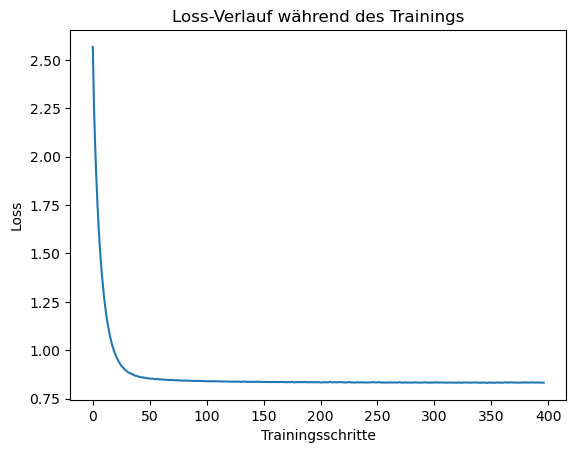

In [39]:
plt.plot(MLPC_classifier.loss_history)
plt.title("Loss-Verlauf während des Trainings")
plt.xlabel("Trainingsschritte")
plt.ylabel("Loss")
plt.show();

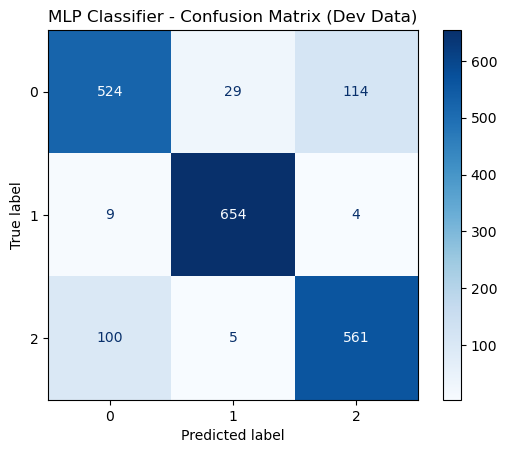

In [40]:
#confusion matrix
cm = confusion_matrix(dev_data["y"].values, dev_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("MLP Classifier - Confusion Matrix (Dev Data)")
plt.show();

## Aufgabe 8 - Activation Functions (5 Punkte) 
Untersuche mit Hilfe des Entwicklungsdatensatzes den Effekt der beiden Aktivierungsfunktionen auf Konvergenzverhalten und Klassifikationsergebnis bei anderweitig gleicher Konfiguration und Hyperparametrisierung. 

Interpretiere und erkläre.

In [41]:
# Modelldefinition mit ReLU und Sigmoid Aktivierungsfunktionen
common_kwargs = dict(
    num_input_neurons=len(dev_predictors.columns),
    num_hidden_neurons=[30, 20],
    num_output_neurons=len(np.unique(dev_target)),
    lr=0.001,
    alpha=0,
    max_num_steps=3000,
    batch_size=32,
    theta_init_range=None,
    suppress_output=True,
    seed=123,
)

relu_model = MLPClassifier(activation_function=ReLU, **common_kwargs)
sigmoid_model = MLPClassifier(activation_function=Sigmoid, **common_kwargs)

relu_model.fit(dev_predictors.values, dev_target.values)
sigmoid_model.fit(dev_predictors.values, dev_target.values)

,num_hidden_neurons,"[30, 20]"
,num_output_neurons,3
,activation_function,<class '__main__.ReLU'>
,loss_function,<class '__mai...ogLikelihood'>
,lr,0.001
,alpha,0
,max_num_steps,3000
,min_relative_improvement,None
,patience,10
,theta_init_range,None
,batch_size,32


,num_hidden_neurons,"[30, 20]"
,num_output_neurons,3
,activation_function,<class '__main__.Sigmoid'>
,loss_function,<class '__mai...ogLikelihood'>
,lr,0.001
,alpha,0
,max_num_steps,3000
,min_relative_improvement,None
,patience,10
,theta_init_range,None
,batch_size,32


In [42]:
# Vorhersagen & Metriken
relu_pred = relu_model.predict(dev_predictors.values)
sigmoid_pred = sigmoid_model.predict(dev_predictors.values)

relu_acc = accuracy_score(dev_y_true, relu_pred)
sigmoid_acc = accuracy_score(dev_y_true, sigmoid_pred)
relu_f1_macro = f1_score(dev_y_true, relu_pred, average="macro")
sigmoid_f1_macro = f1_score(dev_y_true, sigmoid_pred, average="macro")

print("Accuracy; ReLU: {:.4f} | F1 (macro): {:.4f}".format(relu_acc, relu_f1_macro))
print("Accuracy; Sigmoid: {:.4f} | F1 (macro): {:.4f}".format(sigmoid_acc, sigmoid_f1_macro))

Accuracy; ReLU: 0.8755 | F1 (macro): 0.8752
Accuracy; Sigmoid: 0.8760 | F1 (macro): 0.8755


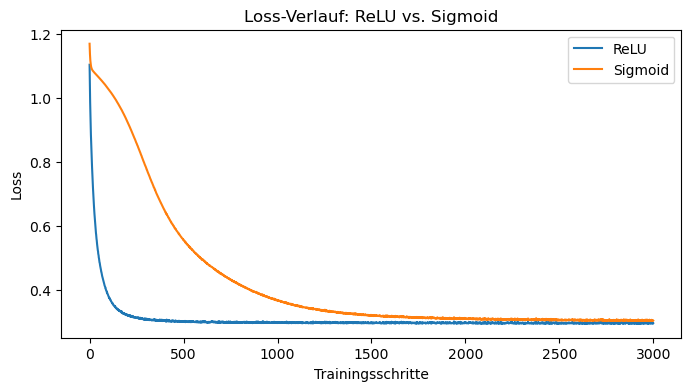

In [43]:
# Loss-Verlauf (Learning Curves)
plt.figure(figsize=(8,4))
plt.plot(relu_model.loss_history, label="ReLU")
plt.plot(sigmoid_model.loss_history, label="Sigmoid")
plt.xlabel("Trainingsschritte")
plt.ylabel("Loss")
plt.title("Loss-Verlauf: ReLU vs. Sigmoid")
plt.legend()
plt.show();

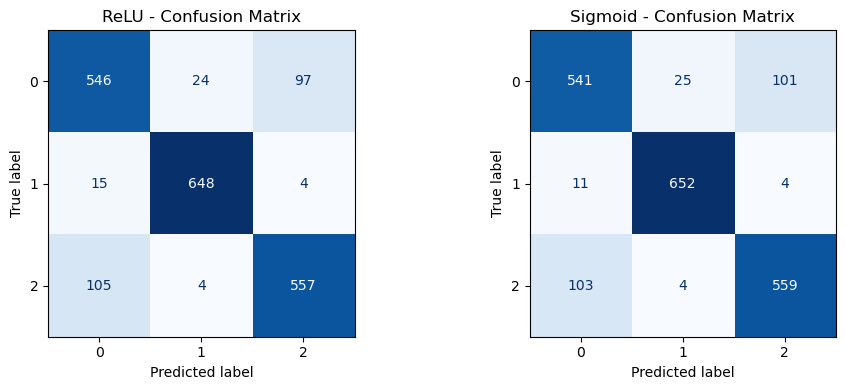

In [44]:
# Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(10,4))
cm_relu = confusion_matrix(dev_y_true, relu_pred)
cm_sig = confusion_matrix(dev_y_true, sigmoid_pred)

disp1 = ConfusionMatrixDisplay(cm_relu)
disp1.plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("ReLU - Confusion Matrix")

disp2 = ConfusionMatrixDisplay(cm_sig)
disp2.plot(ax=axes[1], cmap="Blues", colorbar=False)
axes[1].set_title("Sigmoid - Confusion Matrix")

plt.tight_layout()
plt.show();

### ReLU vs. Sigmoid

#### Beobachtungen

Das MLP lässt sich auf dem Entwicklungsdatensatz mit beiden Aktivierungsfunktionen stabil trainieren. Der Loss sinkt deutlich und geht anschließend in ein Plateau über, sodass eine Konvergenz gegeben ist. Die Klassifikationsgüte ist in beiden Fällen hoch: (Accuracy $\approx$ 0.87 | F1 $\approx$ 0.88).

Im direkten Vergleich zeigen sich nur **kleine Unterschiede** in den Kennzahlen:

* ReLU: Genauigkeit $\approx$ 0,875, Makro-F1 $\approx$ 0,8751
* Sigmoid: Genauigkeit $\approx$ 0,8745, Makro-F1 $\approx$ 0,8743

Die Confusion Matrices zeigen ein sehr ähnliches Fehlerprofil. ReLU erzielt etwas mehr True Positives für Klasse 0, Sigmoid dafür minimal bessere Werte für Klasse 2.
Insgesamt bleibt die Verteilung der Fehlklassifikationen aber sehr ähnlich. Die Modelle unterscheiden sich vor allem graduell und nicht qualitativ.

#### Interpretation

Trotz nahezu identischer Metriken zeigen die Loss-Verläufe den typischen Unterschied zwischen ReLU und Sigmoid:

* **ReLU** führt zu einer schnelleren und etwas stabileren Konvergenz. Das liegt daran, dass ReLU im aktiven Bereich (x > 0) keinen Sättigungseffekt hat und die Gradienten dort groß genug bleiben. Dadurch werden Gewichte in tieferen Schichten effizienter angepasst und das Optimieren wird erleichtert.
* **Sigmoid** neigt in den Extremen (nahe 0 oder 1) zur Sättigung, d. h., die Ableitung wird sehr klein. Dies führt zu langsameren Updates und potenziell stärkeren Vanishing-Gradient-Effekten. Dies spiegelt sich im etwas langsameren und „flacheren“ Abfall der Verlustfunktion wider.

Da die übrige Architektur und die Hyperparameter identisch sind, lässt sich folgern:
Beide Aktivierungsfunktionen sind für diese Aufgabe grundsätzlich geeignet und erreichen eine ähnliche Endleistung. ReLU hat jedoch einen leichten Vorteil in den Bereichen Konvergenzgeschwindigkeit und stabileres Training. Aus praktischer Sicht ist ReLU daher die sinnvollere Standardwahl für weitere Experimente mit diesem MLP.

## Aufgabe 9 - MLP Anwendung (8 Punkte)

In dieser Aufgabe wirst du deine MLP-Implementierung verwenden, um ein bestmögliches Modell für die Vorhersage der Zielvariable `Herzkrankheit` zu entwickeln.

Vergleiche dazu verschiedene Modelle und wähle das beste im Sinne von F1 mit einem geeigneten Verfahren aus.

Berechne weiter jeweils F1 und die Accuracy auf dem Testset und zeichne die Confusion Matrix für das beste Modell.  

Erkläre dein Vorgehen und diskutiere die Resultate.

Verwende `sklearn.pipeline`.

In [45]:
y_train = train_df[TARGET].values
y_test = test_df[TARGET].values
X_train = train_df.drop(columns=[TARGET])
X_test = test_df.drop(columns=[TARGET])

# Reuse the numeric, categorical transformers as well as the preprocessor from before

mlp_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('mlp', MLPClassifier(
        num_hidden_neurons=[64, 32],
        num_output_neurons=2,
        activation_function=ReLU,
        lr=0.01,
        alpha=0.01,
        max_num_steps=2500,
        min_relative_improvement=0.0001,
        patience=50,
        batch_size=32,
        suppress_output=True,
        seed=42,
    ))
])

# Hyperparameter-Grid definieren
mlp_param_grid = {
    'mlp__num_hidden_neurons': [[32], [64, 32], [32, 16], [128, 64, 32]],
    'mlp__lr': [0.001, 0.01, 0.05],
    'mlp__alpha': np.concatenate((np.array([0.0]), np.logspace(-4, -1, 3))),
    'mlp__batch_size': [32, 64, 256]
}

# GridSearchCV using internal F1-Scoring
mlp_gs = GridSearchCV(
    mlp_pipe,
    mlp_param_grid,
    scoring='f1',
    cv=3,           # 3-fold Cross-Validation to shorten executio time
    n_jobs=-1,
    verbose=0
)

mlp_gs.fit(X_train, y_train)

Early Stopping ausgelöst, keine ausreichende Verbesserung des Fehlers.
Early Stopping ausgelöst, keine ausreichende Verbesserung des Fehlers.
Early Stopping ausgelöst, keine ausreichende Verbesserung des Fehlers.
Early Stopping ausgelöst, keine ausreichende Verbesserung des Fehlers.
Early Stopping ausgelöst, keine ausreichende Verbesserung des Fehlers.
Early Stopping ausgelöst, keine ausreichende Verbesserung des Fehlers.
Early Stopping ausgelöst, keine ausreichende Verbesserung des Fehlers.
Early Stopping ausgelöst, keine ausreichende Verbesserung des Fehlers.
Early Stopping ausgelöst, keine ausreichende Verbesserung des Fehlers.
Early Stopping ausgelöst, keine ausreichende Verbesserung des Fehlers.
Early Stopping ausgelöst, keine ausreichende Verbesserung des Fehlers.
Early Stopping ausgelöst, keine ausreichende Verbesserung des Fehlers.
Early Stopping ausgelöst, keine ausreichende Verbesserung des Fehlers.
Early Stopping ausgelöst, keine ausreichende Verbesserung des Fehlers.
Early 

,estimator,"Pipeline(step...0, seed=42))])"
,param_grid,"{'mlp__alpha': array([0. ..., 0.1 ]), 'mlp__batch_size': [32, 64, ...], 'mlp__lr': [0.001, 0.01, ...], 'mlp__num_hidden_neurons': [[32], [64, 32], ...]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [46]:
mlp_results_df = pd.DataFrame(mlp_gs.cv_results_)
top_configs = mlp_results_df.nlargest(5, 'mean_test_score')[
    ['params', 'mean_test_score', 'std_test_score', 'rank_test_score']
]
print("Top 5 Configurations")
display(top_configs)

Top 5 Configurations


,params,mean_test_score,std_test_score,rank_test_score
88,"{'mlp__alpha': 0.0031622776601683794, 'mlp__ba...",0.886870,0.008202,1
28,"{'mlp__alpha': 0.0, 'mlp__batch_size': 256, 'm...",0.883536,0.015460,2
64,"{'mlp__alpha': 0.0001, 'mlp__batch_size': 256,...",0.883536,0.015460,2
104,"{'mlp__alpha': 0.0031622776601683794, 'mlp__ba...",0.883477,0.010763,4
0,"{'mlp__alpha': 0.0, 'mlp__batch_size': 32, 'ml...",0.881817,0.015707,5


In [47]:
best_mlp = mlp_gs.best_estimator_

y_pred_mlp = best_mlp.predict(X_test)
y_proba_mlp_full = best_mlp.predict_proba(X_test)
y_proba_mlp = y_proba_mlp_full[:, 1] if y_proba_mlp_full.shape[1] > 1 else y_proba_mlp_full[:, 0]

mlp_f1 = f1_score(y_test, y_pred_mlp)
mlp_acc = accuracy_score(y_test, y_pred_mlp)

print("Test Set Performance")
print(f"F1 Score: {mlp_f1:.4f}")
print(f"Accuracy: {mlp_acc:.4f}")

Test Set Performance
F1 Score: 0.8465
Accuracy: 0.8391


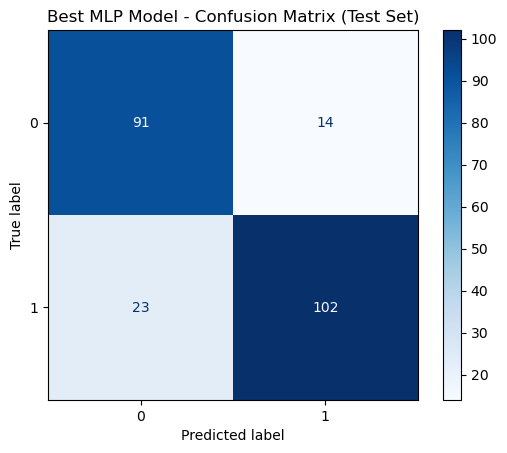

In [48]:
cm_mlp = confusion_matrix(y_test, y_pred_mlp)
disp_mlp = ConfusionMatrixDisplay(confusion_matrix=cm_mlp, display_labels=[0, 1])
disp_mlp.plot(cmap="Blues")
plt.title("Best MLP Model - Confusion Matrix (Test Set)")
plt.show();

In [49]:
print("Comparison with Baseline (Logistic Regression)")
print(f"Logistic Regression - F1: {f1:.4f}, Accuracy: {acc:.4f}")
print(f"Best MLP           - F1: {mlp_f1:.4f}, Accuracy: {mlp_acc:.4f}")
print(f"Improvement        - F1: {mlp_f1 - f1:+.4f}, Accuracy: {mlp_acc - acc:+.4f}")

Comparison with Baseline (Logistic Regression)
Logistic Regression - F1: 0.8819, Accuracy: 0.8696
Best MLP           - F1: 0.8465, Accuracy: 0.8391
Improvement        - F1: -0.0354, Accuracy: -0.0304


### Vorgehen

Für die MLP-Anwendung wird zunächst, analog zu den vorherigen Aufgaben, wieder ein `Pipeline`-Objekt verwendet, das die bereits definierten Vorverarbeitungsschritte (`preprocessor` mit numerischer Skalierung und One-Hot-Encoding der kategorialen Features) mit der `MLPClassifier`-Implementierung kombiniert. Dadurch ist sichergestellt, dass alle Modelle auf identisch vorverarbeiteten Daten arbeiten.

Das MLP wird als mehrschichtiges Netz mit konfigurierbarer Architektur und ReLU-Aktivierung in den Hidden-Layers eingesetzt. Über `GridSearchCV` wird ein Hyperparameter-Grid durchsucht, das u. a. die Anzahl und Größe der Hidden-Layer (`num_hidden_neurons`), die Lernrate (`lr`), die L2-Regularisierung (`alpha`) sowie die Batch-Größe (`batch_size`) variiert. Als Zielmetrik in der Cross-Validation wird F1 gewählt (`scoring="f1"`), um ein gutes Gleichgewicht zwischen Precision und Recall für die Klasse „Herzkrankheit“ zu erzielen. Die Suche erfolgt mit 3-facher Cross-Validation und paralleler Ausführung (`n_jobs=-1`).

Nach Abschluss der Grid-Suche wird das beste gefundene MLP-Modell (`best_estimator_`) auf dem unabhängigen Testset evaluiert. Dabei werden F1-Score und Accuracy berechnet und zusätzlich eine Confusion Matrix geplottet, um die Fehlertypen (False Positives / False Negatives) zu analysieren. Abschließend werden diese Ergebnisse mit der zuvor bestimmten logistischen Regression als Baseline verglichen.


### Resultate und Diskussion

Das beste MLP-Modell erzielt auf dem Testdatensatz einen F1-Score von **0.8465** und eine Accuracy von **0.8391**. Die Confusion Matrix zeigt, dass 102 Patient:innen mit Herzkrankheit korrekt erkannt werden (True Positives), aber 23 Fälle übersehen werden (False Negatives). Umgekehrt werden 91 gesunde Personen korrekt als gesund klassifiziert (True Negatives), während 14 fälschlicherweise als krank eingestuft werden (False Positives). 
Insgesamt erkennt das MLP also die Mehrheit der Erkrankten, produziert jedoch im Vergleich zur Baseline mehr Fehlklassifikationen.

Im direkten Vergleich schneidet die **logistische Regression** als Baseline besser ab (F1 = **0.8819**, Accuracy = **0.8696**) als das beste MLP-Modell (F1 = **0.8465**, Accuracy = **0.8391**). Trotz der höheren Flexibilität und Modellkapazität des MLPs führt die zusätzliche Nichtlinearität hier nicht zu einer Leistungssteigerung, sondern eher zu einer leichten Verschlechterung. Mögliche Gründe sind:

* Die zugrunde liegende Struktur des Problems ist weitgehend (nahezu) linear trennbar, sodass ein lineares Modell wie die logistische Regression bereits sehr gut passt.
* Das MLP hat relativ zur Datensatzgrösse mehr Freiheitsgrade und ist daher anfälliger für Overfitting, selbst mit L2-Regularisierung (`alpha`).
* Die Optimierung des MLP (Lernrate, Architektur, Trainingsteps, Early-Stopping-Kriterium) ist sensibel. Mit begrenztem Suchraum und CV-Budget wird ggf. kein wirklich optimaler Punkt erreicht.

Für die Aufgabe "Beste Vorhersage der Zielvariable Herzkrankheit im Sinne der F1-Metrik" wäre daher die logistische Regression als finales Modell zu bevorzugen. Das ist ein interessantes Ergebnis: ein einfaches, interpretierbares lineares Modell kann je nach Setting mindestens so gut oder sogar besser performen als ein komplexerer, nichtlinearer Ansatz.

Das macht mich traurig und lässt mich die in diese Aufgaben investierte Zeit hinterfragen. :(

## Aufgabe 10 - Decision Tree Theorie (8 Punkte)

Erkläre kurz und präzis wie ein Entscheidungsbaum konstruiert wird. Was für eine Rolle spielen dabei das Unreinheitsmass, die maximale Tiefe, sowie Pruning?

### Konstruktion

Ein Entscheidungsbaum wird **top-down** konstruiert:

1. **Start am Wurzelknoten**

   * Alle Trainingsdaten sind zunächst in einem Knoten.

2. **Suche nach dem besten Split**

   * Für jedes Feature und viele mögliche Schwellenwerte wird berechnet, wie „gut“ der Split die Daten in „reinere“ Teilmengen trennt.
   * Das Kriterium dafür ist das **Unreinheitsmaß** (z. B. Gini, Entropie bei Klassifikation; Varianz bei Regression).
   * Der Split, der die **größte Reduktion der Unreinheit** bringt (größter „Information Gain“), wird gewählt.

3. **Rekursives Aufteilen**

   * Für die entstandenen Kindknoten wiederholt man Schritt 2, bis ein Stoppkriterium erfüllt ist.


###  Unreinheitsmaß & Informationsgewinn

* Das **Unreinheitsmaß** sagt, wie „gemischt“ die Klassen in einem Knoten sind und dient als Kriterium für den besten Split (maximaler Informationsgewinn).

Gegeben ist ein Knotendatensatz $S$ mit Klassen $k = 1, \dots, K$ und Klassenanteilen
$$
p_k = \frac{\text{Anzahl Beispiele der Klasse } k \text{ in } S}{|S|}.
$$

Typische **Unreinheitsmaße** $I(S)$:

* **Entropie**
  $$
  I_{\text{Entropie}}(S) = - \sum_{k=1}^{K} p_k \log_2(p_k)
  $$

* **Gini-Index**
  $$
  I_{\text{Gini}}(S) = \sum_{k=1}^{K} p_k(1 - p_k) = 1 - \sum_{k=1}^{K} p_k^2
  $$

Für einen möglichen Split $Feature (j), Schwelle (t)$ wird $S$ in zwei Teilmengen aufgeteilt:

$$
S_{\text{links}} = { x \in S \mid x_j \le t }, \quad
S_{\text{rechts}} = { x \in S \mid x_j > t }.
$$

Die **gewichtete Unreinheit nach dem Split** ist

$$
I_{\text{nach}} =
\frac{|S_{\text{links}}|}{|S|} I(S_{\text{links}})

* \frac{|S_{\text{rechts}}|}{|S|} I(S_{\text{rechts}}).
$$

Der **Informationsgewinn** (Information Gain) lautet

$
\text{Gain}(S, j, t) = I(S) - I_{\text{nach}}.
$

*Beim Baumaufbau wird für jeden Knoten der Split $(j,t)$ gewählt, der $\text{Gain}$ maximiert.*

### Maximale Tiefe
Die **maximale Tiefe** ist ein vorab definiertes Stoppkriterium gegen Overfitting. Die **Tiefe** eines Knotens ist die Anzahl Schritte von der Wurzel bis zu diesem Knoten.

Die **maximale Tiefe** $d_{\max}$ begrenzt die Rekursion:

* Stoppe das weitere Aufteilen, wenn
  $$
  \text{Tiefe}(Knoten) = d_{\max}.
  $$

Dadurch wird verhindert, dass der Baum immer weiter aufspaltet, bis fast jede Beobachtung in einem eigenen Blatt ist (starkes Overfitting), dafür wird der Bias erhöht.

### Pruning
**Pruning** vereinfacht einen bereits gewachsenen Baum nachträglich mithilfe einer Zielfunktion, die Fehler und Modellkomplexität abwägt.

Oft lässt man den Baum zunächst „zu groß“ werden und **beschneidet ihn danach**.
Eine typische Idee ist **Kosten-Komplexitäts-Pruning**:

Für einen Baum $T$ definiert man eine Zielfunktion

$$
R_\alpha(T) = R(T) + \alpha \cdot |Blätter(T)|,
$$

wobei

* $R(T)$ z. B. der Fehler auf einem Validierungs- oder Trainingsdatensatz ist (Misclassification Rate oder Sum of Squared Errors),
* $|Blätter(T)|$ die Anzahl der Blattknoten,
* $\alpha \ge 0$ ist ein Regularisierungsparameter.

Man wählt einen **pruned tree** $T^*$, der $R_\alpha(T)$ minimiert.
Das entfernt überkomplexe Teilbäume und verbessert die **Generalisation** auf neue Daten.


Konstruiere nun ein einfaches Beispiel, bei welchem die Wahl des Unreinheitsmasses zu einer unterschiedlichen Klassifikation führt bei anderweitig deterministischem Algorithmus und erkläre warum das so ist.

In [50]:
# Feature-Matrix (A, B)
X = np.array([
    [1, 0],
    [1, 1],
    [1, 1],
    [1, 1],
    [1, 0],
    [0, 1],
    [0, 1],
    [1, 0]
])

# Zielvariable y
y = np.array([0, 0, 1, 1, 0, 1, 1, 1])


In [51]:
tree_gini = DecisionTreeClassifier(
    criterion="gini",
    max_depth=1,
    random_state=0
)
tree_gini.fit(X, y)

tree_entropy = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=1,
    random_state=0
)
tree_entropy.fit(X, y)


,criterion,'gini'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


,criterion,'entropy'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


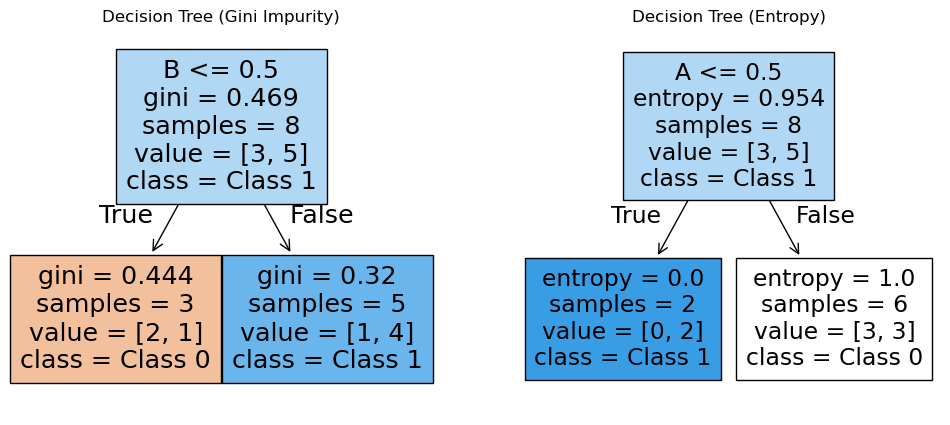

In [52]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plot_tree(
    tree_gini,
    feature_names=["A", "B"],
    class_names=["Class 0", "Class 1"],
    filled=True,
)
plt.title("Decision Tree (Gini Impurity)")  
plt.subplot(1, 2, 2)
plot_tree(
    tree_entropy,
    feature_names=["A", "B"],
    class_names=["Class 0", "Class 1"],
    filled=True,
)
plt.title("Decision Tree (Entropy)")  
plt.show();


In [53]:
points = [(0, 0), (0, 1), (1, 0), (1, 1)]

for p in points:
    pred_gini = tree_gini.predict([p])[0]
    pred_entropy = tree_entropy.predict([p])[0]
    print(f"x={p}:  gini -> {pred_gini},   entropy -> {pred_entropy}")


x=(0, 0):  gini -> 0,   entropy -> 1
x=(0, 1):  gini -> 1,   entropy -> 1
x=(1, 0):  gini -> 0,   entropy -> 0
x=(1, 1):  gini -> 1,   entropy -> 0


### Baum mit gini

#### Wurzel

Gesamt: `samples = 8`, `value = [3, 5]`

$$
p_0 = \frac{3}{8} = 0{,}375,\quad p_1 = \frac{5}{8} = 0{,}625
$$

* **Gini an der Wurzel**:
  $$
  G_{\text{root}} = 1 - (p_0^2 + p_1^2)
  = 1 - (0{,}375^2 + 0{,}625^2)
  = 1 - (0{,}140625 + 0{,}390625)
  = 0{,}46875 \approx 0{,}469
  $$

#### Split nach A ($A \leq 0{,}5$)

Klassengrössen:
$|S_{A=0}| = 2$, $|S_{A=1}|=6$, $|S|=8$

##### Kind 1 (**A=0**: `value = [0, 2]`)

* rein Class 1
$$ 
p_0 = 0, \quad p_1 = 1
$$

$$
G_{A=0} = 0
$$

##### Kind 2 (**A=1**: `value = [3, 3]`)

$$
p_0 = p_1 = 0{,}5
$$

$$
G_{A=1} = 1 - (0{,}5^2 + 0{,}5^2) = 0{,}5
$$

##### Gewichtete Unreinheiten nach dem Split auf A

$$
G_{\text{nach},A} = \frac{2}{8}\cdot 0 + \frac{6}{8}\cdot 0{,}5 = 0{,}375
$$

$$
\text{Gain}_G(A) \approx 0{,}46875 - 0{,}375 = 0{,}09375
$$

#### Split nach B ($B \leq 0{,}5$)

Klassengrössen:
$|S_{B=0}| = 3$, $|S_{B=1}|=5$, $|S|=8$

##### Kind 1 (**B=0**: `value = [2,1]`)

$$
p_0 = \frac{2}{3},\quad p_1 = \frac{1}{3}
$$

$$
G_{B=0} = 1 - \left(\left(\frac{2}{3}\right)^2 + \left(\frac{1}{3}\right)^2\right)
= 1 - \frac{5}{9} = \frac{4}{9} \approx 0{,}444
$$

##### Kind 2 (**B=1**: `value = [1,4]`)

$$
p_0 = \frac{1}{5} = 0{,}2,\quad p_1 = \frac{4}{5} = 0{,}8
$$

$$
G_{B=1} = 1 - (0{,}2^2 + 0{,}8^2) = 1 - (0{,}04 + 0{,}64) = 0{,}32
$$

##### Gewichtete Unreinheiten nach dem Split auf B

$$
G_{\text{nach},B} = \frac{3}{8}\cdot 0{,}444 + \frac{5}{8}\cdot 0{,}32 \approx 0{,}367
$$

$$
\text{Gain}_G(B) = 0{,}46875 - 0{,}367 \approx 0{,}102
$$

#### Entscheidung

$$
\text{Gain}_G(B) \approx 0{,}102 > \text{Gain}_G(A) \approx 0{,}094 \Rightarrow \text{Split auf } B
$$

---

### Baum mit Entropy

#### Wurzel

Gesamt: `samples = 8`, `value = [3, 5]`

$$
p_0 = \frac{3}{8} = 0{,}375,\quad p_1 = \frac{5}{8} = 0{,}625
$$

* **Entropie an der Wurzel**:
  $$
  H_{\text{root}}
  = -\bigl(p_0 \cdot \log_2 (p_0) + p_1 \cdot \log_2 (p_1)\bigr)
  \approx 0{,}954
  $$

#### Split nach A ($A \leq 0{,}5$)

Klassengrössen:
$|S_{A=0}| = 2$, $|S_{A=1}|=6$, $|S|=8$

##### Kind 1 (**A=0**: `value = [0, 2]`)

* rein Class 1

$$
p_0 = 0, \quad p_1 = 1
$$

$$
H_{A=0} = 0
$$

##### Kind 2 (**A=1**: `value = [3, 3]`)

$$
p_0 = p_1 = 0{,}5
$$

$$
H_{A=1} = -\bigl(0{,}5 \cdot \log_2 (0{,}5) + 0{,}5 \cdot\log_2 (0{,}5)\bigr) = 1
$$

##### Gewichtete Unreinheiten nach dem Split auf A

$$
H_{\text{nach},A} = \frac{2}{8}\cdot 0 + \frac{6}{8}\cdot 1 = 0{,}75
$$

$$
\text{Gain}_H(B) \approx 0{,}954 - 0{,}75 = 0{,}204
$$

#### Split nach B ($B \leq 0{,}5$)

Klassengrössen:
$|S_{B=0}| = 3$, $|S_{B=1}|=5$, $|S|=8$

##### Kind 1 (**B=0**: `value = [2,1]`)

$$
p_0 = \frac{2}{3},\quad p_1 = \frac{1}{3}
$$

$$
H_{B=0} = -\left( \frac{2}{3} \cdot \log_2 \left(\frac{2}{3}\right) + \frac{1}{3} \cdot\log_2 \left(\frac{1}{3}\right) \right) \approx 0{,}918
$$

##### Kind 2 (**B=1**: `value = [1,4]`)

$$
p_0 = 0{,}2,\quad p_1 = 0{,}8
$$

$$
H_{B=1} = -\bigl( 0{,}2 \cdot \log_2 (0{,}2) +  0{,}8 \cdot\log_2 ( 0{,}8) \bigr) \approx 0{,}722
$$

##### Gewichtete Unreinheiten nach dem Split auf B

$$
H_{\text{nach},B} = \frac{3}{8}\cdot 0{,}918 + \frac{5}{8}\cdot 0{,}722 \approx 0{,}796
$$

$$
\text{Gain}_H(B) \approx 0{,}954 - 0{,}796 = 0{,}159
$$

#### Entscheidung

$$
\text{Gain}_H(A) \approx 0{,}204 > \text{Gain}_H(B) \approx 0{,}159 \Rightarrow \text{Split auf } A
$$

Entsprechend teilt der **Gini-Baum** nach **B**, der **Entropie-Baum** hingegen nach **A**. Dadurch landen bestimmte Punkte (z.B. $x=(0,0)$, $x=(1,1)$) in unterschiedlichen Blättern mit unterschiedlichen Mehrheitsklassen, es gibt unterschiedliche Vorhersagen.

**Entropie** reagiert typischerweise stärker auf sehr reine Teilknoten, auch wenn sie klein sind. Der komplett reine Knoten $A=0$ (2× Klasse 1) wird von der Entropie daher stärker „belohnt“. **Gini** dagegen ist etwas "flacher" und gewichtet die 3/2- und 4/1-Verteilungen bei $B$ so, dass insgesamt der Split auf $B$ minimal mehr bringt.


## Aufgabe 11 - Decision Tree Anwendung (6 Punkte)

Entwickle und evaluiere (analog zu Aufgabe 8) nun ein bestmögliches Decision Tree-Modell für die Vorhersage der Zielvariable.

Du darfst hierbei beliebige scikit-learn-Funktionen verwenden.

Zeichne den gefundenen Baum und erkläre ihn.

In [54]:
# Preprocessing-Pipeline
preprocessor_dt = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ]
)

# Pipeline mit Decision Tree
dt_pipe = Pipeline([
    ('preprocessor', preprocessor_dt),
    ('dt', DecisionTreeClassifier(random_state=42))
])

# Hyperparameter-Grid für Decision Tree
dt_param_grid = {
    'dt__criterion': ['gini', 'entropy'],
    'dt__max_depth': [3, 5, 7, 10, 15, None],
    'dt__min_samples_split': [2, 5, 10, 20],
    'dt__min_samples_leaf': [1, 2, 4, 8],
    'dt__max_features': ['sqrt', 'log2', None],
    'dt__class_weight': [None, 'balanced']
}

# GridSearchCV mit F1-Scoring
dt_gs = GridSearchCV(
    dt_pipe,
    dt_param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=0
)

dt_gs.fit(X_train, y_train)

print("Best Decision Tree Parameters")
print(dt_gs.best_params_)
print(f"Best CV F1 Score: {dt_gs.best_score_:.4f}")

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'dt__class_weight': [None, 'balanced'], 'dt__criterion': ['gini', 'entropy'], 'dt__max_depth': [3, 5, ...], 'dt__max_features': ['sqrt', 'log2', ...], ...}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


Best Decision Tree Parameters
{'dt__class_weight': 'balanced', 'dt__criterion': 'gini', 'dt__max_depth': 10, 'dt__max_features': None, 'dt__min_samples_leaf': 8, 'dt__min_samples_split': 20}
Best CV F1 Score: 0.8778


In [55]:
# Evaluate best Decision Tree on test set
best_dt = dt_gs.best_estimator_

y_pred_dt = best_dt.predict(X_test)
y_proba_dt_full = best_dt.predict_proba(X_test)
y_proba_dt = y_proba_dt_full[:, 1] if y_proba_dt_full.shape[1] > 1 else y_proba_dt_full[:, 0]

dt_f1 = f1_score(y_test, y_pred_dt)
dt_acc = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Performance on Test Set")
print(f"F1 Score: {dt_f1:.4f}")
print(f"Accuracy: {dt_acc:.4f}")

Decision Tree Performance on Test Set
F1 Score: 0.8182
Accuracy: 0.8087


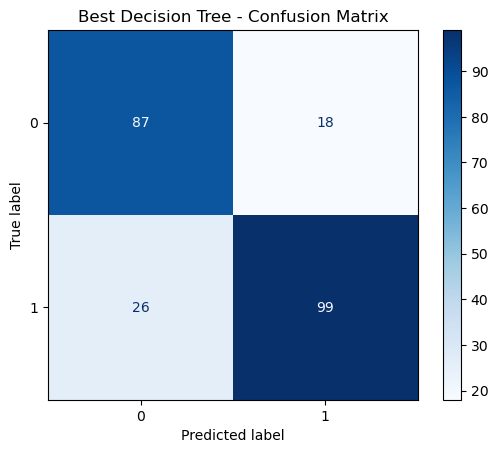

In [56]:
# Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=[0, 1])
disp_dt.plot(cmap="Blues")
plt.title("Best Decision Tree - Confusion Matrix")
plt.show();

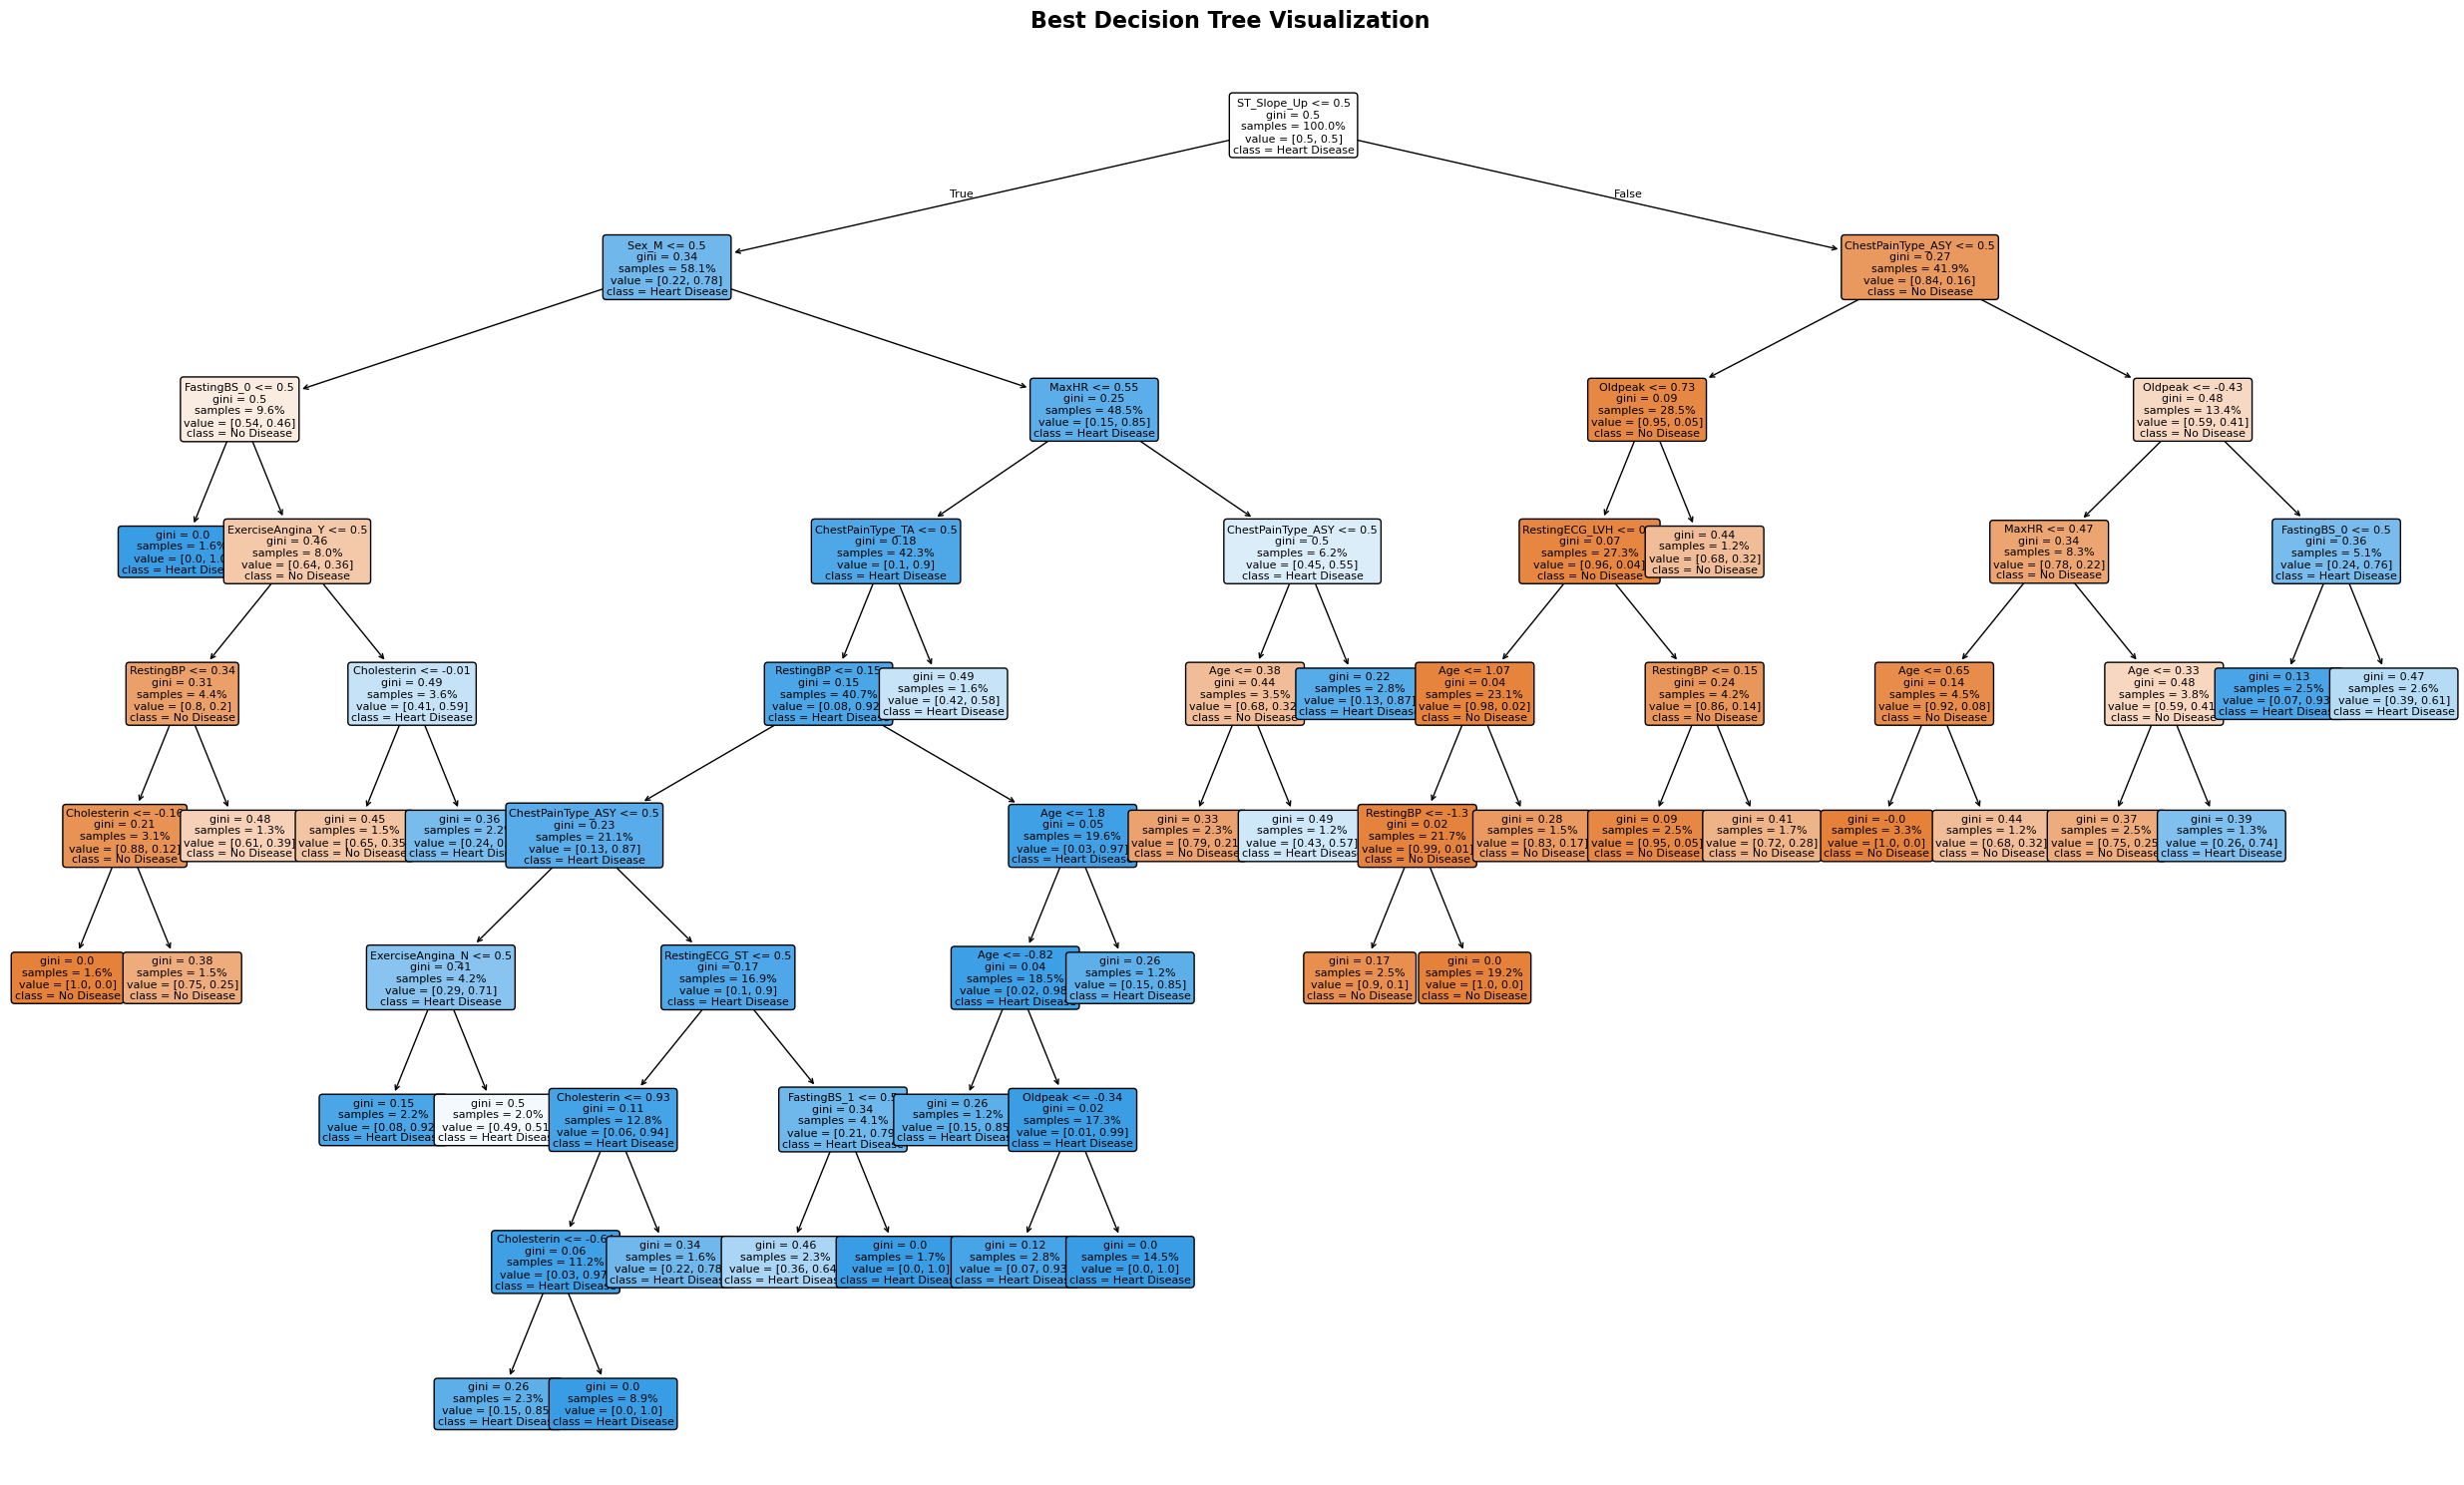

In [57]:
# Plot the Decision Tree
fig, ax = plt.subplots(figsize=(25, 15))

# Extract the actual DecisionTreeClassifier from the pipeline
dt_model = best_dt.named_steps['dt']

# Get feature names after preprocessing
preprocessor_fitted = best_dt.named_steps['preprocessor']
feature_names = []

for name, transformer, columns in preprocessor_fitted.transformers_:
    if name == 'num':
        feature_names.extend(columns)
    elif name == 'cat':
        # Get feature names from OneHotEncoder
        feature_names.extend(transformer.get_feature_names_out(columns))

# Create the tree plot with improved parameters
plot_tree(
    dt_model,
    feature_names=feature_names,
    class_names=['No Disease', 'Heart Disease'],
    filled=True,
    rounded=True,
    fontsize=8,
    proportion=True, 
    precision=2,
    impurity=True,
    ax=ax
)

plt.title("Best Decision Tree Visualization", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()

plt.show();

### Interpretation

Der Baum verwendet im Wurzelknoten die Variable `ST_Slope_Up`.
`ST_Slope_Up <= 0.5` trennt Patienten mit *nicht-aufsteigender* ST-Strecke (linker Ast, überwiegend **Herzkrankheit**, blau) von Patienten mit *aufsteigender* ST-Strecke (rechter Ast, überwiegend **kein Herzleiden**, orange). Das deckt sich mit den medizinischen Erkenntnissen: Eine horizontale oder absinkende ST-Strecke ist eher verdächtig auf Ischämie (DocCheck, n.d.)

#### Linker Teilbaum (tendenziell „höheres Risiko“)

* Im ersten Schritt wird nach `Sex_M`gesplittet. Im linken Ast landen vor allem Patient:innen, bei denen der Indikator `Sex_M`=0 ist (also eher Frauen), im rechten Ast `Sex_M`=1 (eher Männer). Besonders im "männlichen" Ast dominiert die Klasse "Herzerkrankungen", was ebenfalls der Erwartung entspricht: Männer leiden deutlich häufiger an Herzerkrankungen (Rethemioti, 2024).
* Bei einem Ast wird dann `FastingBS_0` und danach `ExerciseAngina_Y` verwendet: Kombinationen aus *nicht normalem Nüchternzucker* bzw. *Belastungsangina* erhöhen die Herzkrankheits-Wahrscheinlichkeit. (Xu et al., 2015)
* Im anderen Ast wird zunächst die **maximale Herzfrequenz (`MaxHR`)** und dann der **Brustschmerztyp (`ChestPainType_TA`)** herangezogen: Eine niedrigere MaxHR und typische Angina (TA) führen zu sehr reinen „Herzkrankheit“-Blättern (dunkelblau, niedriger Gini). Auch das entspricht unseren Erwartungnen. (Wong et al., 2015)

Insgesamt beschreibt der linke Teilbaum somit mehrere Hochrisikoprofile mit nicht aufsteigender ST-Strecke, ungünstigem Brustschmerztyp, eingeschränkter Belastbarkeit (MaxHR) sowie teilweise pathologischem Blutzucker bzw. Belastungsangina.

#### Rechter Teilbaum (tendenziell „niedrigeres Risiko“)

* Der erste Knoten ist **`ChestPainType_ASY`**: `ChestPainType_ASY <= 0.5` (kein asymptomatischer Brustschmerz) führt zu einem großen, sehr sauberen „kein Herzleiden“-Knoten (viel Orange, Gini $\approx$ 0.27).
* Darunter wird vor allem mit **`Oldpeak`** (ST-Senkung in mm), **`RestingECG_LVH`** (Linksherzhypertrophie im Ruhe-EKG) und **`MaxHR`** weiter verfeinert:
  * Geringe ST-Senkung und unauffälliges EKG sprechen für *keine* Herzkrankheit (sehr niedrige Gini-Werte, z. B. 0.07).
  * Nur in einem kleinen Ast kippt das wieder Richtung **Herzkrankheit**: Patienten mit bestimmten `Oldpeak`-Werten und nicht normalem Nüchternzucker (`FastingBS_0 <= 0.5`) werden als krank klassifiziert (hellblauer Knoten).

#### Performance des Baums

Auf dem Testset erreicht das beste Baum-Modell:

* **F1-Score:** 0.8182
* **Accuracy:** 0.8087

Die Confusion Matrix bedeutet: 99 Erkrankte werden korrekt als solche erkannt (True Positives), 26 werden übersehen (False Negatives). 87 gesunde Personen werden korrekt als gesund klassifiziert, 18 werden fälschlicherweise als krank eingestuft (False Positives).
Der Baum liefert somit eine solide, etwas konservative Klassifikation mit einem guten Kompromiss aus Recall (ca. 79 % der Kranken werden erkannt) und Precision (ca. 85 % der als krank Klassifizierten sind tatsächlich krank). Gleichzeitig sind die Entscheidungsregeln gut interpretierbar.

#### Quellen:
- DocCheck, M. B. (n.d.). ST-Senkung - DocCheck Flexikon. DocCheck Flexikon. https://flexikon.doccheck.com/de/ST-Senkung
- Rethemiotaki, I. (2024). Global prevalence of cardiovascular diseases by gender and age during 2010–2019. Archives of Medical Science - Atherosclerotic Diseases, 8(1), 196–205. https://doi.org/10.5114/amsad/176654
- Xu, T., Liu, W., Cai, X., Ding, J., Tang, H., Huang, Y., & Hu, Y. (2015). Risk of coronary heart disease in different criterion of impaired fasting glucose. Medicine, 94(40), e1740. https://doi.org/10.1097/md.0000000000001740
- Wong, Y., Stearn, S., Moore, S., & Hale, B. (2015). Angina at Low heart rate And Risk of imminent Myocardial infarction (the ALARM study): a prospective, observational proof-of-concept study. BMC Cardiovascular Disorders, 15(1), 148. https://doi.org/10.1186/s12872-015-0140-z

## Aufgabe 12 - Weitere Klassifikationsalgorithmen (9 Punkte)

Vergleiche nun mindestens drei weitere sinnvolle Klassifikations-Methoden. Du bist dabei frei, beliebige scikit-learn Modelle zur Vorhersage der Zielvariablen zu verwenden, um jeweils eine möglichst gute Vorhersage im Sinne Zielmetrik F1 zu erreichen.

Berechne jeweils weiter den F1-Score, die Accuracy und zeichne die Confusion Matrix auf den Testdaten.

### Klassifikationsmethoden:

**k-Nearest Neighbors (KNN)**: 
KNN sagt die Klasse einer Beobachtung anhand der *k* nächsten Trainingspunkte im Merkmalsraum vorher. Es ist ein einfaches, nicht-parametrisches Verfahren, das gut nichtlineare Entscheidungsgrenzen abbilden kann.

**Random Forest**: 
Random Forest kombiniert viele Entscheidungsbäume, die jeweils auf Bootstrap-Samples und zufälligen Feature-Subsets trainiert werden. Durch dieses Bagging-Verfahren werden Varianz und Overfitting einzelner Bäume reduziert.

**Gradient Boosting**: 
Gradient Boosting baut viele schwache Entscheidungsbäume nacheinander auf, wobei jeder neue Baum die Fehler der vorherigen korrigiert. Dadurch entsteht ein starkes, additives Modell, das komplexe nichtlineare Zusammenhänge erfassen kann.

**Support Vector Machine (SVM)**: 
Die SVM sucht eine Trennhyperfläche, die den maximalen Abstand (Margin) zwischen den Klassen hat; mit Kerneln sind auch nichtlineare Grenzen möglich.

In [58]:
results = {}

# Grid for Random Forest Classifier
rf_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('rf', RandomForestClassifier(random_state=42))
])

rf_param_grid = {
    'rf__n_estimators': [100, 200, 300],
    'rf__max_depth': [10, 15, 20, None],
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf': [1, 2, 4],
    'rf__max_features': ['sqrt', 'log2'],
    'rf__class_weight': [None, 'balanced']
}


# Grid for  Gradient Boosting Classifier
gb_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('gb', GradientBoostingClassifier(random_state=42))
])

gb_param_grid = {
    'gb__n_estimators': [100, 200, 300],
    'gb__learning_rate': [0.01, 0.05, 0.1],
    'gb__max_depth': [3, 5, 7],
    'gb__min_samples_split': [2, 5, 10],
    'gb__min_samples_leaf': [1, 2, 4],
    'gb__subsample': [0.8, 1.0]
}


# Grid for  Support Vector Machine
svm_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('svm', SVC(random_state=42, probability=True))
])

svm_param_grid = {
    'svm__C': [0.1, 1.0, 10.0, 100.0],
    'svm__kernel': ['rbf', 'poly', 'sigmoid'],
    'svm__gamma': ['scale', 'auto'],
    'svm__class_weight': [None, 'balanced']
}


# Grid for  K-Nearest Neighbors Classifier
knn_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('knn', KNeighborsClassifier())
])

knn_param_grid = {
    'knn__n_neighbors': [3, 5, 7, 9, 11, 15],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan', 'minkowski'],
    'knn__p': [1, 2]
}


In [59]:
def eval_pipeline(
        pipe: Pipeline, 
        grid_params: dict,
        model_name: str
    ):
    """GridSearchCV (5-fold) -> best_estimator_; dann 5-fold CV Scores + Test-Metriken."""
    print(f"Training: {model_name}...")
    grid = GridSearchCV(
        estimator=pipe,
        param_grid=grid_params,
        scoring="f1",
        cv=5,
        n_jobs=-1,
        refit=True,
        verbose=0
    )

    grid.fit(X_train, y_train)
    best_est = grid.best_estimator_
    
    # Test-Metriken
    yhat_test = best_est.predict(X_test)
    f1_test = f1_score(y_test, yhat_test)
    acc_test = accuracy_score(y_test, yhat_test)

    # CV scores from best estimator (for stripplots)
    cv_f1_scores = cross_val_score(best_est, X_train, y_train, cv=5, scoring="f1", n_jobs=-1)
    cv_acc_scores = cross_val_score(best_est, X_train, y_train, cv=5, scoring="accuracy", n_jobs=-1)

    # Für Übersichtstabelle (Durchschnitte)
    summary = {
        "model": model_name,
        "best_params": grid.best_params_,
        "cv_f1_mean": float(np.mean(cv_f1_scores)),
        "cv_f1_std": float(np.std(cv_f1_scores)),
        "cv_acc_mean": float(np.mean(cv_acc_scores)),
        "cv_acc_std": float(np.std(cv_acc_scores)),
        "test_f1": float(f1_test),
        "test_accuracy": float(acc_test)
    }
    return summary, best_est, (cv_f1_scores, cv_acc_scores)

In [60]:
models = [
    (rf_pipe, rf_param_grid, "Random Forest"),
    (gb_pipe, gb_param_grid, "Gradient Boosting"),
    (svm_pipe, svm_param_grid, "Support Vector Machine"),
    (knn_pipe, knn_param_grid, "K-Nearest Neighbors"),
]

all_results = []
best_estimators = {}
cv_scores_dict = {}

for estimator, grid_params, model_name in models:
    summary, best_est, cv_scores = eval_pipeline(estimator, grid_params, model_name)
    all_results.append(summary)
    best_estimators[model_name] = best_est
    cv_scores_dict[model_name] = cv_scores

results_df = pd.DataFrame(all_results).sort_values(by="test_f1", ascending=False)

Training: Random Forest...
Training: Gradient Boosting...
Training: Support Vector Machine...
Training: K-Nearest Neighbors...


In [61]:
display(results_df)

,model,best_params,cv_f1_mean,cv_f1_std,cv_acc_mean,cv_acc_std,test_f1,test_accuracy
3,K-Nearest Neighbors,"{'knn__metric': 'manhattan', 'knn__n_neighbors...",0.892069,0.016017,0.876452,0.018934,0.880952,0.869565
2,Support Vector Machine,"{'svm__C': 1.0, 'svm__class_weight': None, 'sv...",0.887279,0.012078,0.870623,0.014924,0.875502,0.865217
0,Random Forest,"{'rf__class_weight': None, 'rf__max_depth': 10...",0.898413,0.016309,0.883751,0.019861,0.859438,0.847826
1,Gradient Boosting,"{'gb__learning_rate': 0.1, 'gb__max_depth': 7,...",0.894455,0.015312,0.879350,0.017005,0.804979,0.795652


### Prepare Logistic Regression, MLP and DescisionTree

In [62]:
prev_models = {
    "Decision Tree": best_dt,
    "MLP Classifier": best_mlp,
    "Logistic Regression": best_lr
}


def eval_previous_model(
        model_name: str,
        model: Pipeline
    ):
    """Evaluate previous models (Decision Tree, MLP, Logistic Regression)"""
    print(f"Evaluating: {model_name}...")
    # CV Scores
    cv_f1_scores = cross_val_score(model, X_train, y_train, cv=5, scoring="f1", n_jobs=-1)
    cv_acc_scores = cross_val_score(model, X_train, y_train, cv=5, scoring="accuracy", n_jobs=-1)

    # Test Metrics
    yhat_test = model.predict(X_test)
    f1_test = f1_score(y_test, yhat_test)
    acc_test = accuracy_score(y_test, yhat_test)

    summary = {
        "model": model_name,
        "best_params": model.get_params(),
        "cv_f1_mean": float(np.mean(cv_f1_scores)),
        "cv_f1_std": float(np.std(cv_f1_scores)),
        "cv_acc_mean": float(np.mean(cv_acc_scores)),
        "cv_acc_std": float(np.std(cv_acc_scores)),
        "test_f1": float(f1_test),
        "test_accuracy": float(acc_test)
    }
    return summary, (cv_f1_scores, cv_acc_scores)


for model_name, model in prev_models.items():
    prev_summary, prev_scores = eval_previous_model(model_name, model)
    results_df = pd.concat([results_df, pd.DataFrame([prev_summary])], ignore_index=True)
    cv_scores_dict[model_name] = prev_scores

# Sortieren der Ergebnisse nach Test F1-Score
results_df = results_df.sort_values(by="test_f1", ascending=False).reset_index(drop=True)

Evaluating: Decision Tree...
Evaluating: MLP Classifier...
Early Stopping ausgelöst, keine ausreichende Verbesserung des Fehlers.
Early Stopping ausgelöst, keine ausreichende Verbesserung des Fehlers.
Early Stopping ausgelöst, keine ausreichende Verbesserung des Fehlers.
Early Stopping ausgelöst, keine ausreichende Verbesserung des Fehlers.
Early Stopping ausgelöst, keine ausreichende Verbesserung des Fehlers.
Early Stopping ausgelöst, keine ausreichende Verbesserung des Fehlers.
Early Stopping ausgelöst, keine ausreichende Verbesserung des Fehlers.
Early Stopping ausgelöst, keine ausreichende Verbesserung des Fehlers.
Early Stopping ausgelöst, keine ausreichende Verbesserung des Fehlers.
Early Stopping ausgelöst, keine ausreichende Verbesserung des Fehlers.
Evaluating: Logistic Regression...


### Model Comparison Summary

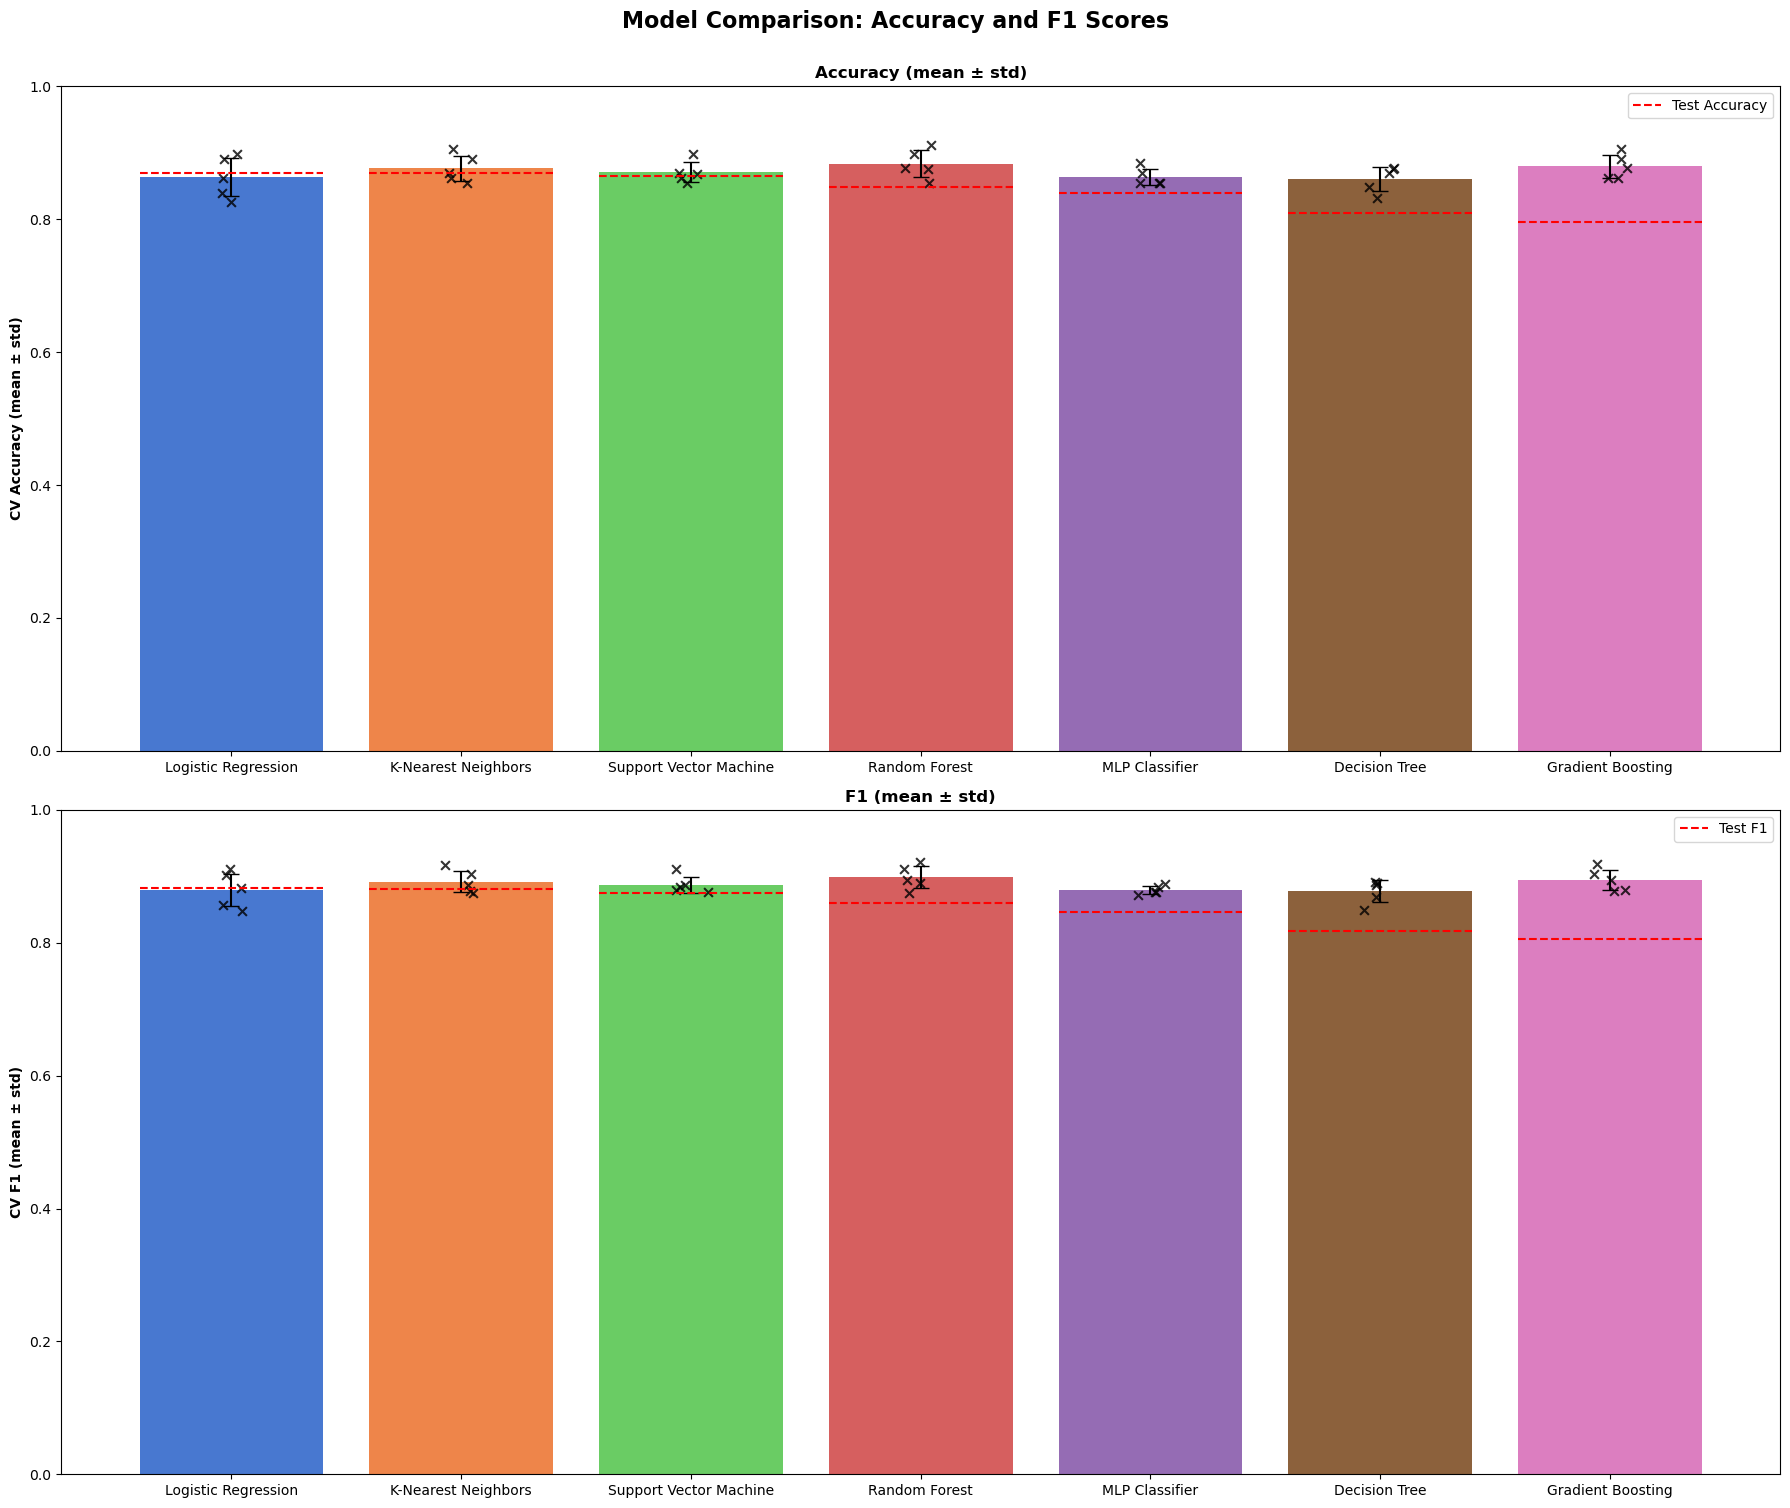

In [63]:
# Compare CV accuracy and F1 (mean ± std with fold points)
models = results_df['model'].tolist()
cv_acc_means = results_df['cv_acc_mean'].values
cv_acc_stds  = results_df['cv_acc_std'].values
cv_f1_means = results_df['cv_f1_mean'].values
cv_f1_stds  = results_df['cv_f1_std'].values
test_acc = results_df[["model", 'test_accuracy']]
test_f1  = results_df[["model", 'test_f1']]

x = np.arange(len(models))
fig, axes = plt.subplots(2, 1, figsize=(18, 15))

colors = sns.color_palette("muted", n_colors=len(models))

# CV Accuracy
ax = axes[0]
bars = ax.bar(x, cv_acc_means, yerr=cv_acc_stds, capsize=6, color=colors)
ax.set_xticks(x)
ax.set_xticklabels(models, ha='center')
ax.set_ylabel("CV Accuracy (mean ± std)", fontweight='bold')
ax.set_ylim(0, 1)
ax.set_title("Accuracy (mean ± std)", fontweight='bold')
    
# overlay individual CV fold scores for accuracy
for i, m in enumerate(models):
    scores = cv_scores_dict.get(m)[1]
    if scores is not None:
        jitter = (np.random.rand(len(scores)) - 0.5) * 0.15
        ax.scatter(np.full_like(scores, i) + jitter, scores, color="k", alpha=0.8, s=40, marker="x")
    
    ax.hlines(test_acc[test_acc['model'] == m]['test_accuracy'].values[0], 
              xmin=i - 0.4, xmax=i + 0.4, 
              colors='r', 
              linestyles='dashed', 
              label='Test Accuracy' if i == 0 else ""
              )

ax.legend()

# CV F1
ax = axes[1]
bars = ax.bar(x, cv_f1_means, yerr=cv_f1_stds, capsize=6, color=colors)
ax.set_xticks(x)
ax.set_xticklabels(models, ha='center')
ax.set_ylabel("CV F1 (mean ± std)", fontweight='bold')
ax.set_ylim(0, 1)
ax.set_title("F1 (mean ± std)", fontweight='bold')

# overlay individual CV fold scores for F1
for i, m in enumerate(models):
    scores = cv_scores_dict.get(m)
    if scores is not None:
        jitter = (np.random.rand(len(scores[0])) - 0.5) * 0.15
        ax.scatter(np.full_like(scores[0], i) + jitter, scores[0], color="k", alpha=0.8, s=40, marker="x")
    
    ax.hlines(
        test_f1[test_f1['model'] == m]['test_f1'].values[0], 
              xmin=i - 0.4, xmax=i + 0.4, 
              colors='r', 
              linestyles='dashed', 
              label='Test F1' if i == 0 else ""
              )

ax.legend()

plt.suptitle("Model Comparison: Accuracy and F1 Scores", fontsize=16, fontweight='bold', y=1.002)
plt.tight_layout()
plt.show();

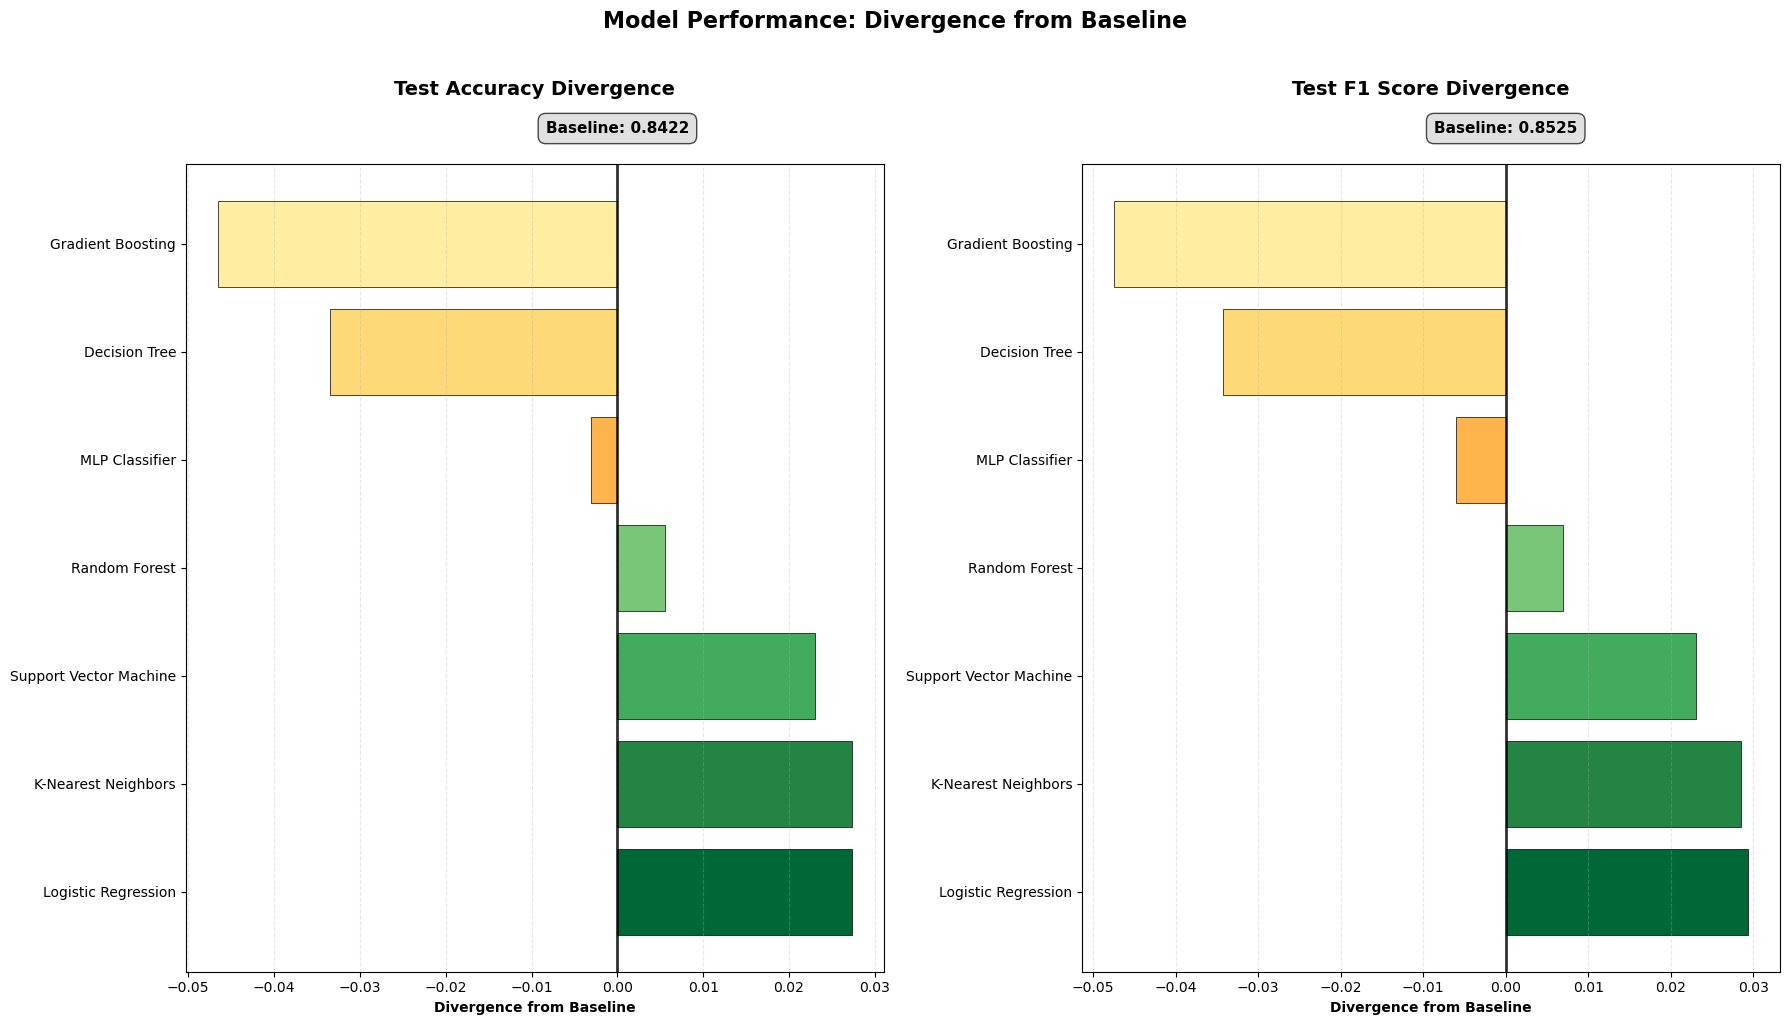

In [ ]:
test_acc = results_df['test_accuracy'].values
test_f1 = results_df['test_f1'].values

# Calculate divergence from baseline (mean of all models)
baseline_acc = test_acc.mean()
baseline_f1 = test_f1.mean()

# Calculate divergence
acc_divergence = test_acc - baseline_acc
f1_divergence = test_f1 - baseline_f1

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

colors_pos = sns.color_palette("YlGn_r", n_colors=len(models))
colors_neg = sns.color_palette("YlOrRd_r", n_colors=len(models))


# --- Accuracy Divergent Plot ---
ax = axes[0]
y_pos = np.arange(len(models))

# Color bars based on positive/negative divergence
bar_colors_acc = [colors_pos[i] if val >= 0 else colors_neg[i] for i, val in enumerate(acc_divergence)]

bars = ax.barh(
    y_pos, 
    acc_divergence, 
    color=bar_colors_acc, 
    edgecolor='black', 
    linewidth=0.5
)

# baseline line
ax.axvline(0, color='black', linestyle='-', linewidth=2, alpha=0.8)
ax.text(
    0, 
    len(models), 
    f'Baseline: {baseline_acc:.4f}', 
    ha='center', 
    va='bottom', 
    fontsize=11, 
    fontweight='bold',
    bbox=dict(
        boxstyle='round,pad=0.5',
        facecolor='lightgray',
        alpha=0.7
        )
)

ax.set_yticks(y_pos)
ax.set_yticklabels(models)
ax.set_xlabel('Divergence from Baseline', fontweight='bold')
ax.set_title('Test Accuracy Divergence', fontsize=14, fontweight='bold', y=1.075)
ax.grid(axis='x', alpha=0.3, linestyle='--')


# --- F1 Divergent Plot ---
ax = axes[1]

# Color bars based on positive/negative divergence
bar_colors_f1 = [colors_pos[i] if val >= 0 else colors_neg[i] for i, val in enumerate(f1_divergence)]

bars = ax.barh(
    y_pos, 
    f1_divergence, 
    color=bar_colors_f1, 
    edgecolor='black', 
    linewidth=0.5
)

#  baseline line
ax.axvline(
    0, 
    color='black', 
    linestyle='-', 
    linewidth=2, 
    alpha=0.8
)

ax.text(0, len(models), f'Baseline: {baseline_f1:.4f}', 
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold',
        bbox=dict(
            boxstyle='round,pad=0.5', 
            facecolor='lightgray', 
            alpha=0.7
        )
)

ax.set_yticks(y_pos)
ax.set_yticklabels(models)
ax.set_xlabel('Divergence from Baseline', fontweight='bold')
ax.set_title('Test F1 Score Divergence', fontsize=14, fontweight='bold', y=1.075)
ax.grid(axis='x', alpha=0.3, linestyle='--')

plt.suptitle('Model Performance: Divergence from Baseline', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show();

### Confusion Matrices

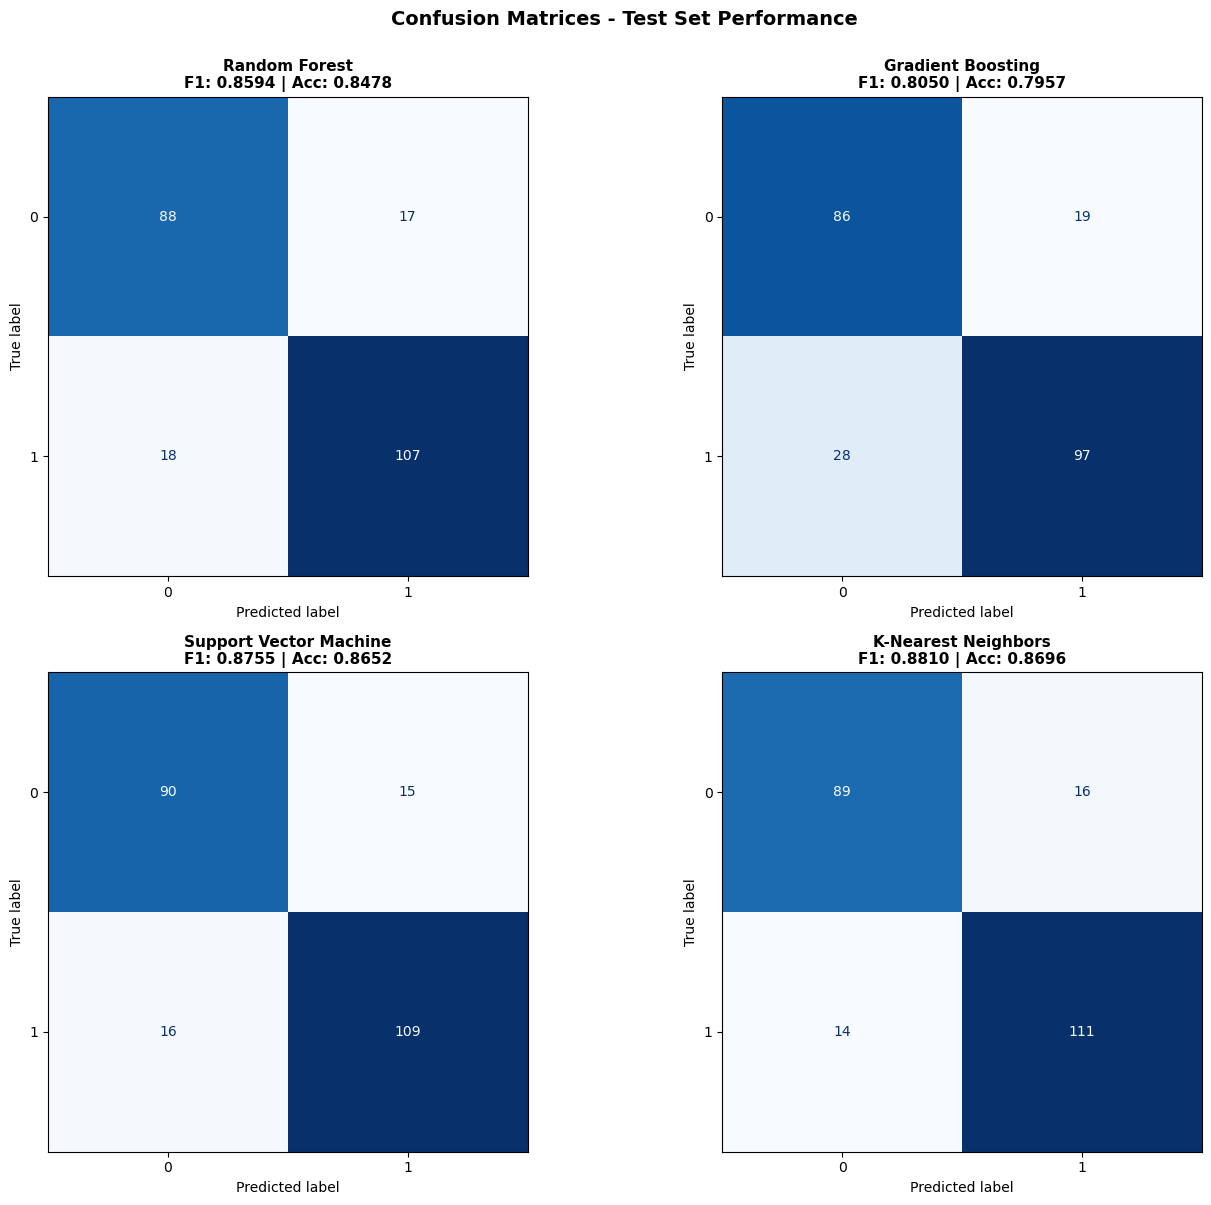

In [ ]:
# Create confusion matrices for all 4 models in a 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

# Model names and predictions
model_names = ["Random Forest", "Gradient Boosting", "Support Vector Machine", "K-Nearest Neighbors"]

# Get predictions for each model
model_predictions = {}
for model_name in model_names:
    best_est = best_estimators[model_name]
    model_predictions[model_name] = best_est.predict(X_test)

# Plot confusion matrices
for idx, model_name in enumerate(model_names):
    ax = axes[idx]
    y_pred_model = model_predictions[model_name]
    
    # Compute confusion matrix
    cm = confusion_matrix(y_test, y_pred_model)
    
    # Display confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    
    # Get metrics for title
    f1 = f1_score(y_test, y_pred_model)
    acc = accuracy_score(y_test, y_pred_model)
    
    ax.set_title(f"{model_name}\nF1: {f1:.4f} | Acc: {acc:.4f}", fontsize=11, fontweight='bold')

plt.suptitle("Confusion Matrices - Test Set Performance", fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show();